In [1]:
#%%time
import re
import gzip
import math
import random
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.sparse import issparse

from ast import literal_eval
import warnings
# 忽略 FutureWarning 类型警告
warnings.simplefilter(action='ignore', category=FutureWarning)
# 忽略特定类型的警告：忽略 scanpy包中含有 ignore 的 UserWarning 类型警告
warnings.filterwarnings("ignore", category=UserWarning, module="scanpy")
# 禁用 pandas 包中的 SettingWithCopyWarning 类型警告
pd.options.mode.chained_assignment = None  # 或 'raise' 表示引发异常

import inferECC
from inferECC import *

species value: hg38
species == 'mm10':  False


In [2]:
###### 举例1个样本表示，单个样本的异质性

In [3]:
def get_all_folders(path):
    folders = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]
    return folders
"""
# 指定路径
target_path = library_dir # '/your/target/directory'
# 获取所有文件夹
folders_list = get_all_folders(target_path)
"""

"\n# 指定路径\ntarget_path = library_dir # '/your/target/directory'\n# 获取所有文件夹\nfolders_list = get_all_folders(target_path)\n"

In [101]:
### anno ecdna2gene oncogene pathway
### import ecdna2gene2pathway function

import warnings
import scanpy as sc
from ast import literal_eval
from collections import Counter

cancer_gene_tb = pd.read_csv("D:/02.project/18.ecDNA/02.method/ref/hg19/cancer_gene_census_20240307.txt",sep="\t")
cancer_gene_list = list(cancer_gene_tb["Gene Symbol"].unique())

# DataFrame :: gene_unique_list is the column list of elements that match oncogenes
def custom_transform(element):
    if isinstance(element, list):
        # Extract the intersection of the element list with oncogene_list
        return list(set(element) & set(cancer_gene_list))
    else:
        # If the element is NaN, then return NaN
        return element
### step 1
# Apply the custom function custom_transform to the gene_unique_list column
#df['oncogene'] = df['gene_unique_list'].apply(custom_transform)

# Define a function to process elements in the oncogene column:: convert oncogene_nor element value 0 to []
def process_gene_list(item):
    # If the element is the integer 0, return an empty list
    if item == 0:
        return []
    # Otherwise, return the original element
    else:
        return item
# Define a function to process elements in the oncogene_nor column:: merge oncogene_nor list
def merge_gene_list(gene_list):
    # Create an empty list to store the results
    result = []
    for item in gene_list:
        # If the element is a list, add its elements to the result
        if isinstance(item, list):
            result.extend(item)
    return result
# Define a function to process elements in the oncogene_nor column
def process_oncogene_nor(oncogene_nor, top_n=15):
    # Use Counter to count the frequency of elements
    counter = Counter(oncogene_nor)
    # Extract the top_n elements with the highest frequency
    most_common = counter.most_common(top_n) # 6/15
    # Form a list with these top_n elements
    result = [item[0] for item in most_common]
    return result
### Main function merge
def group_merge(df=pd.DataFrame(), group_columns_name="group", raw_columns_name="oncogene"):
    df_ecdna_gene = df.copy()
    # Use the apply function
    df_ecdna_gene[raw_columns_name+"_nor"] = df_ecdna_gene[raw_columns_name].apply(process_gene_list)
    # Use groupby and apply functions
    df_ecdna_gene_grouped = df_ecdna_gene.groupby(group_columns_name)[raw_columns_name+"_nor"].apply(merge_gene_list).reset_index()
    # Convert the label column to Categorical type and specify the order of categories
    df_ecdna_gene_grouped[group_columns_name] = pd.Categorical(df_ecdna_gene_grouped[group_columns_name],
                                                    categories=list(df_ecdna_gene[group_columns_name].unique()),
                                                    ordered=True)
    # Use the sort_values function to sort
    df_ecdna_gene_grouped = df_ecdna_gene_grouped.sort_values(group_columns_name)
    # Use the apply function
    df_ecdna_gene_grouped['most_'+raw_columns_name+"_nor"] = df_ecdna_gene_grouped[raw_columns_name+"_nor"].apply(process_oncogene_nor)
    return df_ecdna_gene_grouped

### step 2
# Apply the custom function group_merge to the gene oncogene column
#df_merge = group_merge(df_ecdna_gene_oncogene, "group")



###共性基因功能注释：：
# highest_expr_top_n
import gseapy as gp
from gseapy.plot import barplot, dotplot
"""
names = gp.get_library_name()
# Create a DataFrame from the list
df = pd.DataFrame(names, columns=['Name'])
# Save the DataFrame to a CSV file
df.to_csv("./fig/gseapy_gene-sets.txt", index=False)
"""

import pandas as pd
# 定义一个函数来处理字符串
def process_term(term):
    # 检查倒数第12个到倒数第9个字符是否为'(GO:'
    if term[-12:-8] == '(GO:':
        # 如果是，则删除倒数第11个字符之后的所有字符
        return term[:-12]
    else:
        # 否则，返回原字符串
        return term

def gp_enrichr(gene_list,sample,path,gene_sets):
    # 假设你已经有了差异基因列表
    diff_genes = gene_list
    #diff_genes = new_df[new_df["cluster"]=="C3"]["gene"].to_list()
    #diff_genes = new_df["gene"].to_list()
    # 运行GSEA
    # enrichr库包含了大量的基因集，选择其中的一个，例如'KEGG_2019_Human'\'MSigDB_Hallmark_2020'
    enr = gp.enrichr(gene_list=diff_genes,
                     gene_sets=['MSigDB_Hallmark_2020',
                                #'KEGG_2021_Human',
                                #'GO_Biological_Process_2023',
                                #'GO_Molecular_Function_2023',
                                #'GO_Cellular_Component_2023'
                               ],
                     #outdir='./fig/pdac/gseapy',
                     outdir=None,
                     cutoff=0.05)
    
    enr.results["Term_raw"]=enr.results["Term"]
    # 使用apply函数应用到'Term'列
    enr.results["Term"] = enr.results["Term"].apply(process_term)
    # trim (go:...)
    #enr.results["Term"] = enr.results["Term"].str.split(" \(GO").str[0]
    # 根据'A'列的值对df进行排序
    enr_results_sorted = enr.results.sort_values(by='P-value')
    enr_results_sorted['cluster'] = sample
    enr_results_sorted.to_csv(path+"/"+sample+"_enrichr_result.tsv",sep="\t",index=True)
    
    # categorical scatterplot
    #ax = barplot(enr_results_sorted,
    #             #column="Adjusted P-value",
    #             column="P-value",
    #             #group='Gene_set', # set group, so you could do a multi-sample/library comparsion
    #             #size=10,
    #             top_term=30,
    #             #figsize=(10,6*len(enr.results[enr.results["P-value"] <= 0.05])/50),
    #             figsize=(35,12),
    #             color=['blue'] # set colors for group
    #             #color = {'KEGG_2021_Human': 'salmon', 'MSigDB_Hallmark_2020':'darkblue'}
    #             )
    #plt.grid(False)
    #plt.savefig(path+"/"+sample+"_enrichr_barplot.pdf")
    return enr_results_sorted

In [4]:
def find_resolution(adata_temp, n_clusters, tol=0.01, max_iter=100):
    """
    Funuction：find_scanpy_leiden_resolution
    Args:
        adata_temp: [anndata.AnnData]adata_temp. #AnnData对象
        n_clusters: [Numpy.int]n_clusters. #期望的聚类数量
        tol=0.01: #实际的聚类数量与期望的聚类数量的差异的精度
        max_iter=100: #迭代次数
    Returns:
        [Numpy.int].
    """
    # 初始化变量
    adata_temp = adata_temp.copy()
    # 初始化resolution的值
    min_res, max_res = 0.0, 1.0
    # 初始化最佳的resolution和聚类数量
    best_res = None
    best_clusters = np.inf
    for _ in range(max_iter):
        # 计算当前的resolution
        cur_res = (min_res + max_res) / 2.0
        # 使用当前的resolution进行聚类
        sc.tl.leiden(adata_temp, resolution=cur_res)
        # 计算当前的聚类数量
        cur_clusters = adata_temp.obs['leiden'].nunique()
        
        # 如果当前的聚类数量更接近目标聚类数量，就更新最佳的 resolution和聚类数量
        if np.abs(cur_clusters - n_clusters) < np.abs(best_clusters - n_clusters):
            best_res = cur_res
            best_clusters = cur_clusters
        # 如果当前的聚类数量接近期望的数量，就返回当前的 resolution
        if np.abs(cur_clusters - n_clusters) <= tol:
            return cur_res
        # 否则，根据当前的聚类数量调整resolution的值
        if cur_clusters < n_clusters:
            min_res = cur_res
        else:
            max_res = cur_res
    # 如果经过max_iter次迭代后，仍然没有找到满足条件的resolution，就返回最佳的resolution
    return best_res
"""
# 假设adata_temp是你的AnnData对象
# 假设你期望的聚类数量是 4
resolution = find_resolution(adata_temp, n_clusters=4)
"""

'\n# 假设adata_temp是你的AnnData对象\n# 假设你期望的聚类数量是 4\nresolution = find_resolution(adata_temp, n_clusters=4)\n'

In [5]:
def scanpy_base(path,outpath,cancer="cancer",sample="sample",n_clusters=2):
    os.chdir(path)
    print(os.getcwd())
    #adata = sc.read(path+"/cellXecDNA_merge_df.matrix.h5ad")
    #adata = sc.read(path+"/cellXecDNA_fi.matrix_01.h5ad")
    #adata = sc.read(path+"/cellXecDNA_fi.matrix.h5ad")
    adata = sc.read(path+"/cellXecDNA_fi.matrix_fi_background_mean3std.h5ad")
    #lib_name = re.sub("(-fragments.tsv.gz|-atac_fragments.tsv.gz)$", "", path.split("htan_atac_merge")[1])
    lib_name = str(cancer)+": "+str(sample)

    if(os.path.exists(outpath) != True): os.makedirs(outpath)
    os.chdir(outpath)
    print(os.getcwd())
    
    # 过滤低质量细胞
    sc.pp.filter_cells(adata, min_genes=1)
    sc.pp.filter_genes(adata, min_cells=1)
    
    # f01
    fig, ax = plt.subplots(figsize=(16, 13))
    sc.pl.highest_expr_genes(adata, n_top=30, ax=ax, show=False)
    plt.title(str(lib_name))
    plt.tight_layout(pad=13.0)
    fig.savefig("f01-highest_amplified_ecdna.pdf", bbox_inches='tight')
    #plt.close(fig)
    
    # calculate_qc_metrics
    adata.var['chr19'] = adata.var_names.str.startswith('chr19') # annotate the group of chr19 ecdna_regions as 'chr19'
    sc.pp.calculate_qc_metrics(adata, qc_vars=['chr19'], percent_top=None, log1p=False, inplace=True)
    adata.obs["n_ecdna_regions"]=adata.obs["n_genes"]
    adata.obs["total_coverages"]=adata.obs["total_counts"]
    adata.obs["pct_coverages_chr19"]=adata.obs["pct_counts_chr19"]
    
    # 标准化表达矩阵
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    #sc.pp.highly_variable_genes(adata, n_top_genes=10)
    #sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=np.inf, min_disp=0.5)
    sc.pp.highly_variable_genes(adata, min_mean=0.00125, max_mean=np.inf, min_disp=-2)
    
    # 创建一个新的figure对象
    #fig, ax = plt.subplots(figsize=(16, 16))
    # 在这个figure对象上绘制图像
    sc.pl.highly_variable_genes(adata, show=False)
    # 获取高度可变基因的名字和坐标
    hvg = adata.var[adata.var['highly_variable']]
    for gene in hvg.index:
        x = hvg.loc[gene, 'means']
        y = hvg.loc[gene, 'dispersions_norm']
        plt.annotate(gene, (x, y))
        pass
    plt.title(str(lib_name))
    plt.tight_layout(pad=13.0)
    # 保存图像为PDF文件
    plt.savefig("f02-highly_variable_genes.pdf", bbox_inches='tight')
    plt.close(fig)

    adata.raw = adata
    adata = adata[:, adata.var.highly_variable]
    #sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])
    sc.pp.scale(adata)
    sc.tl.pca(adata)
    #sc.pl.pca_variance_ratio(adata, log=True)
    
    # cluster
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)
    resolution_best = find_resolution(adata, n_clusters=n_clusters)
    print("resolution_best: "+str(resolution_best))
    sc.tl.leiden(adata, resolution=resolution_best)
    
    # create a dictionary to map cluster to annotation label
    unique_leiden_values = adata.obs['leiden'].unique()
    cluster2annotation = {value: f'C{value}' for value in unique_leiden_values}
    # add a new `.obs` column called `cell type` by mapping clusters to annotation using pandas `map` function
    adata.obs['cell_type'] = adata.obs['leiden'].map(cluster2annotation).astype('category')

    # 生成颜色列表
    from matplotlib.colors import to_hex
    hex_colors = [to_hex(color) for color in sns.color_palette()]
    cancer_pal = sns.color_palette(hex_colors)
    
    # f02
    fig, ax = plt.subplots(figsize=(5, 5))
    sc.pl.umap(adata, 
               color='cell_type', 
               add_outline=True, 
               #legend_loc='on data',
               legend_loc='right margin',
               legend_fontsize=12, 
               legend_fontoutline=2,
               frameon=False,
               ax=ax,
               show=False,
               title=cancer+":"+sample, 
               palette=cancer_pal)
    #plt.title(str(lib_name))
    # 添加迷你的xy坐标轴
    mini_ax = fig.add_axes([0.15, 0.15, 0.2, 0.2], frame_on=False)  # 在左下角添加一个新的坐标轴，不显示边框
    mini_ax.set_xticks([])  # 不显示x轴的刻度
    mini_ax.set_yticks([])  # 不显示y轴的刻度
    mini_ax.set_xlabel('UMAP1')  # 设置x轴的名称
    mini_ax.set_ylabel('UMAP2')  # 设置y轴的名称
    # 添加箭头
    mini_ax.arrow(0, 0, 1, 0, head_width=0.15, head_length=0.2, fc='k', ec='k')
    mini_ax.arrow(0, 0, 0, 1, head_width=0.15, head_length=0.2, fc='k', ec='k')
    plt.tight_layout(pad=13)
    fig.savefig("f03-cell_clustering.pdf", bbox_inches='tight')
    
    # 按照 cell_type 分组计算差异基因，给定基因排序
    sc.tl.rank_genes_groups(adata, groupby='cell_type', method='wilcoxon') 
    # method::'t-test'/'t-test_overestim_var'/'wilcoxon'/'logreg'
    
    # f04
    fig, ax = plt.subplots(figsize=(15, 1.8))
    sc.pl.rank_genes_groups_dotplot(adata, n_genes=5, 
                                    values_to_plot='logfoldchanges', 
                                    min_logfoldchange=0.5, 
                                    vmax=1.5, vmin=-1.5, 
                                    figsize=(9,1.8),
                                    ax=ax,
                                    cmap='bwr')
    plt.tight_layout(pad=13.0)
    fig.savefig("f04-bubble_list.pdf", bbox_inches='tight')
    
    # f05
    try:
        fig, ax = plt.subplots(figsize=(12, 1.6))
        sc.pl.rank_genes_groups_matrixplot(adata, n_genes=3, 
                                           use_raw=False, 
                                           vmin=-1.5, vmax=1.5, 
                                           ax=ax,
                                           cmap='bwr', 
                                           figsize=(7,1.6))
        plt.tight_layout(pad=13.0)
        fig.savefig("f05-square_list.pdf", bbox_inches='tight')
    except KeyError as e:
        # 处理异常的代码
        pass
    else:
        # 如果没有异常发生，执行这个代码块
        pass
    finally:
        # 无论是否引发异常，都会执行这个代码块
        pass
        
    # f06
    fig, ax = plt.subplots(figsize=(13, 2))
    sc.pl.rank_genes_groups_stacked_violin(adata, n_genes=5, 
                                           cmap='viridis_r', 
                                           ax=ax,
                                           figsize=(8,2))
    plt.tight_layout(pad=13.0)
    fig.savefig("f06-violin_list.pdf", bbox_inches='tight')
    
    # f07
    # 获取每一类的top10 marker基因
    marker_genes = {}
    for cluster in adata.uns['rank_genes_groups']['names'].dtype.names:
        marker_genes[cluster] = adata.uns['rank_genes_groups']['names'][cluster][:15]
    # 替换 'group_key' 和 'marker_genes' 为你的聚类结果的键值和计算出的marker基因
    #fig, ax = plt.subplots(figsize=(8, 6))
    
    # 获取每个cluster的top10差异基因
    clusters = adata.obs['cell_type'].cat.categories
    top_genes = {}
    for cluster in clusters:
        genes = adata.uns['rank_genes_groups']['names'][cluster]
        top_genes[cluster] = genes[:10]
    
    # 绘制每个基因对应的UMAP图
    for cluster, genes in top_genes.items():
        i=0
        for gene in genes:
            i+=1
            sc.pl.umap(adata,
                       cmap='jet',add_outline=True, 
                       legend_loc='right margin',
                       color=gene, title=gene,
                       legend_fontsize=12, 
                       legend_fontoutline=2,
                       frameon=False,
                       palette='Set1',
                       show=False)
            # 添加迷你的xy坐标轴
            mini_ax = fig.add_axes([0.15, 0.15, 0.2, 0.2], frame_on=False)  # 在左下角添加一个新的坐标轴，不显示边框
            mini_ax.set_xticks([])  # 不显示x轴的刻度
            mini_ax.set_yticks([])  # 不显示y轴的刻度
            mini_ax.set_xlabel('UMAP1')  # 设置x轴的名称
            mini_ax.set_ylabel('UMAP2')  # 设置y轴的名称
            # 添加箭头
            mini_ax.arrow(0, 0, 1, 0, head_width=0.15, head_length=0.2, fc='k', ec='k')
            mini_ax.arrow(0, 0, 0, 1, head_width=0.15, head_length=0.2, fc='k', ec='k')
            plt.tight_layout(pad=13.0)
            plt.savefig(f"f09_{cluster}_{i}_umap.png", dpi=300, bbox_inches='tight')
            plt.close()
            pass
            
    return adata

In [6]:
all_path = "D:/02.project/18.ecDNA/01.result/result_htan/htan_atac_merge/"
out_path = "E:/05.project/04.ecDNA/02.result/result_htan/htan_atac_merge_m3std/"
#cancer_list = get_all_folders(all_path)[5:]
cancer_list = get_all_folders(all_path)
cancer_list

['BRCA', 'CEAD', 'CESC', 'CRC', 'HNSCC', 'MM', 'OV', 'PDAC', 'SKCM', 'UCEC']

In [7]:
cancer = "BRCA"
sample = "ht128b1-s1h4-fragments.tsv.gz"
lib_dir = all_path+cancer+"/"+sample+"/ks_uniform_qsub"
out_dir = out_path+cancer+"/"+sample+"/ks_uniform_qsub_nclus4"

#adata_cluster = scanpy_base(path=lib_dir,outpath=out_dir,cancer=cancer,n_clusters=4,sample="ht128b1-s1h4")

In [8]:
path=lib_dir
outpath=out_dir
cancer=cancer
n_clusters=4
sample="ht128b1-s1h4"

D:\02.project\18.ecDNA\01.result\result_htan\htan_atac_merge\BRCA\ht128b1-s1h4-fragments.tsv.gz\ks_uniform_qsub
E:\05.project\04.ecDNA\02.result\result_htan\htan_atac_merge_m3std\BRCA\ht128b1-s1h4-fragments.tsv.gz\ks_uniform_qsub_nclus4


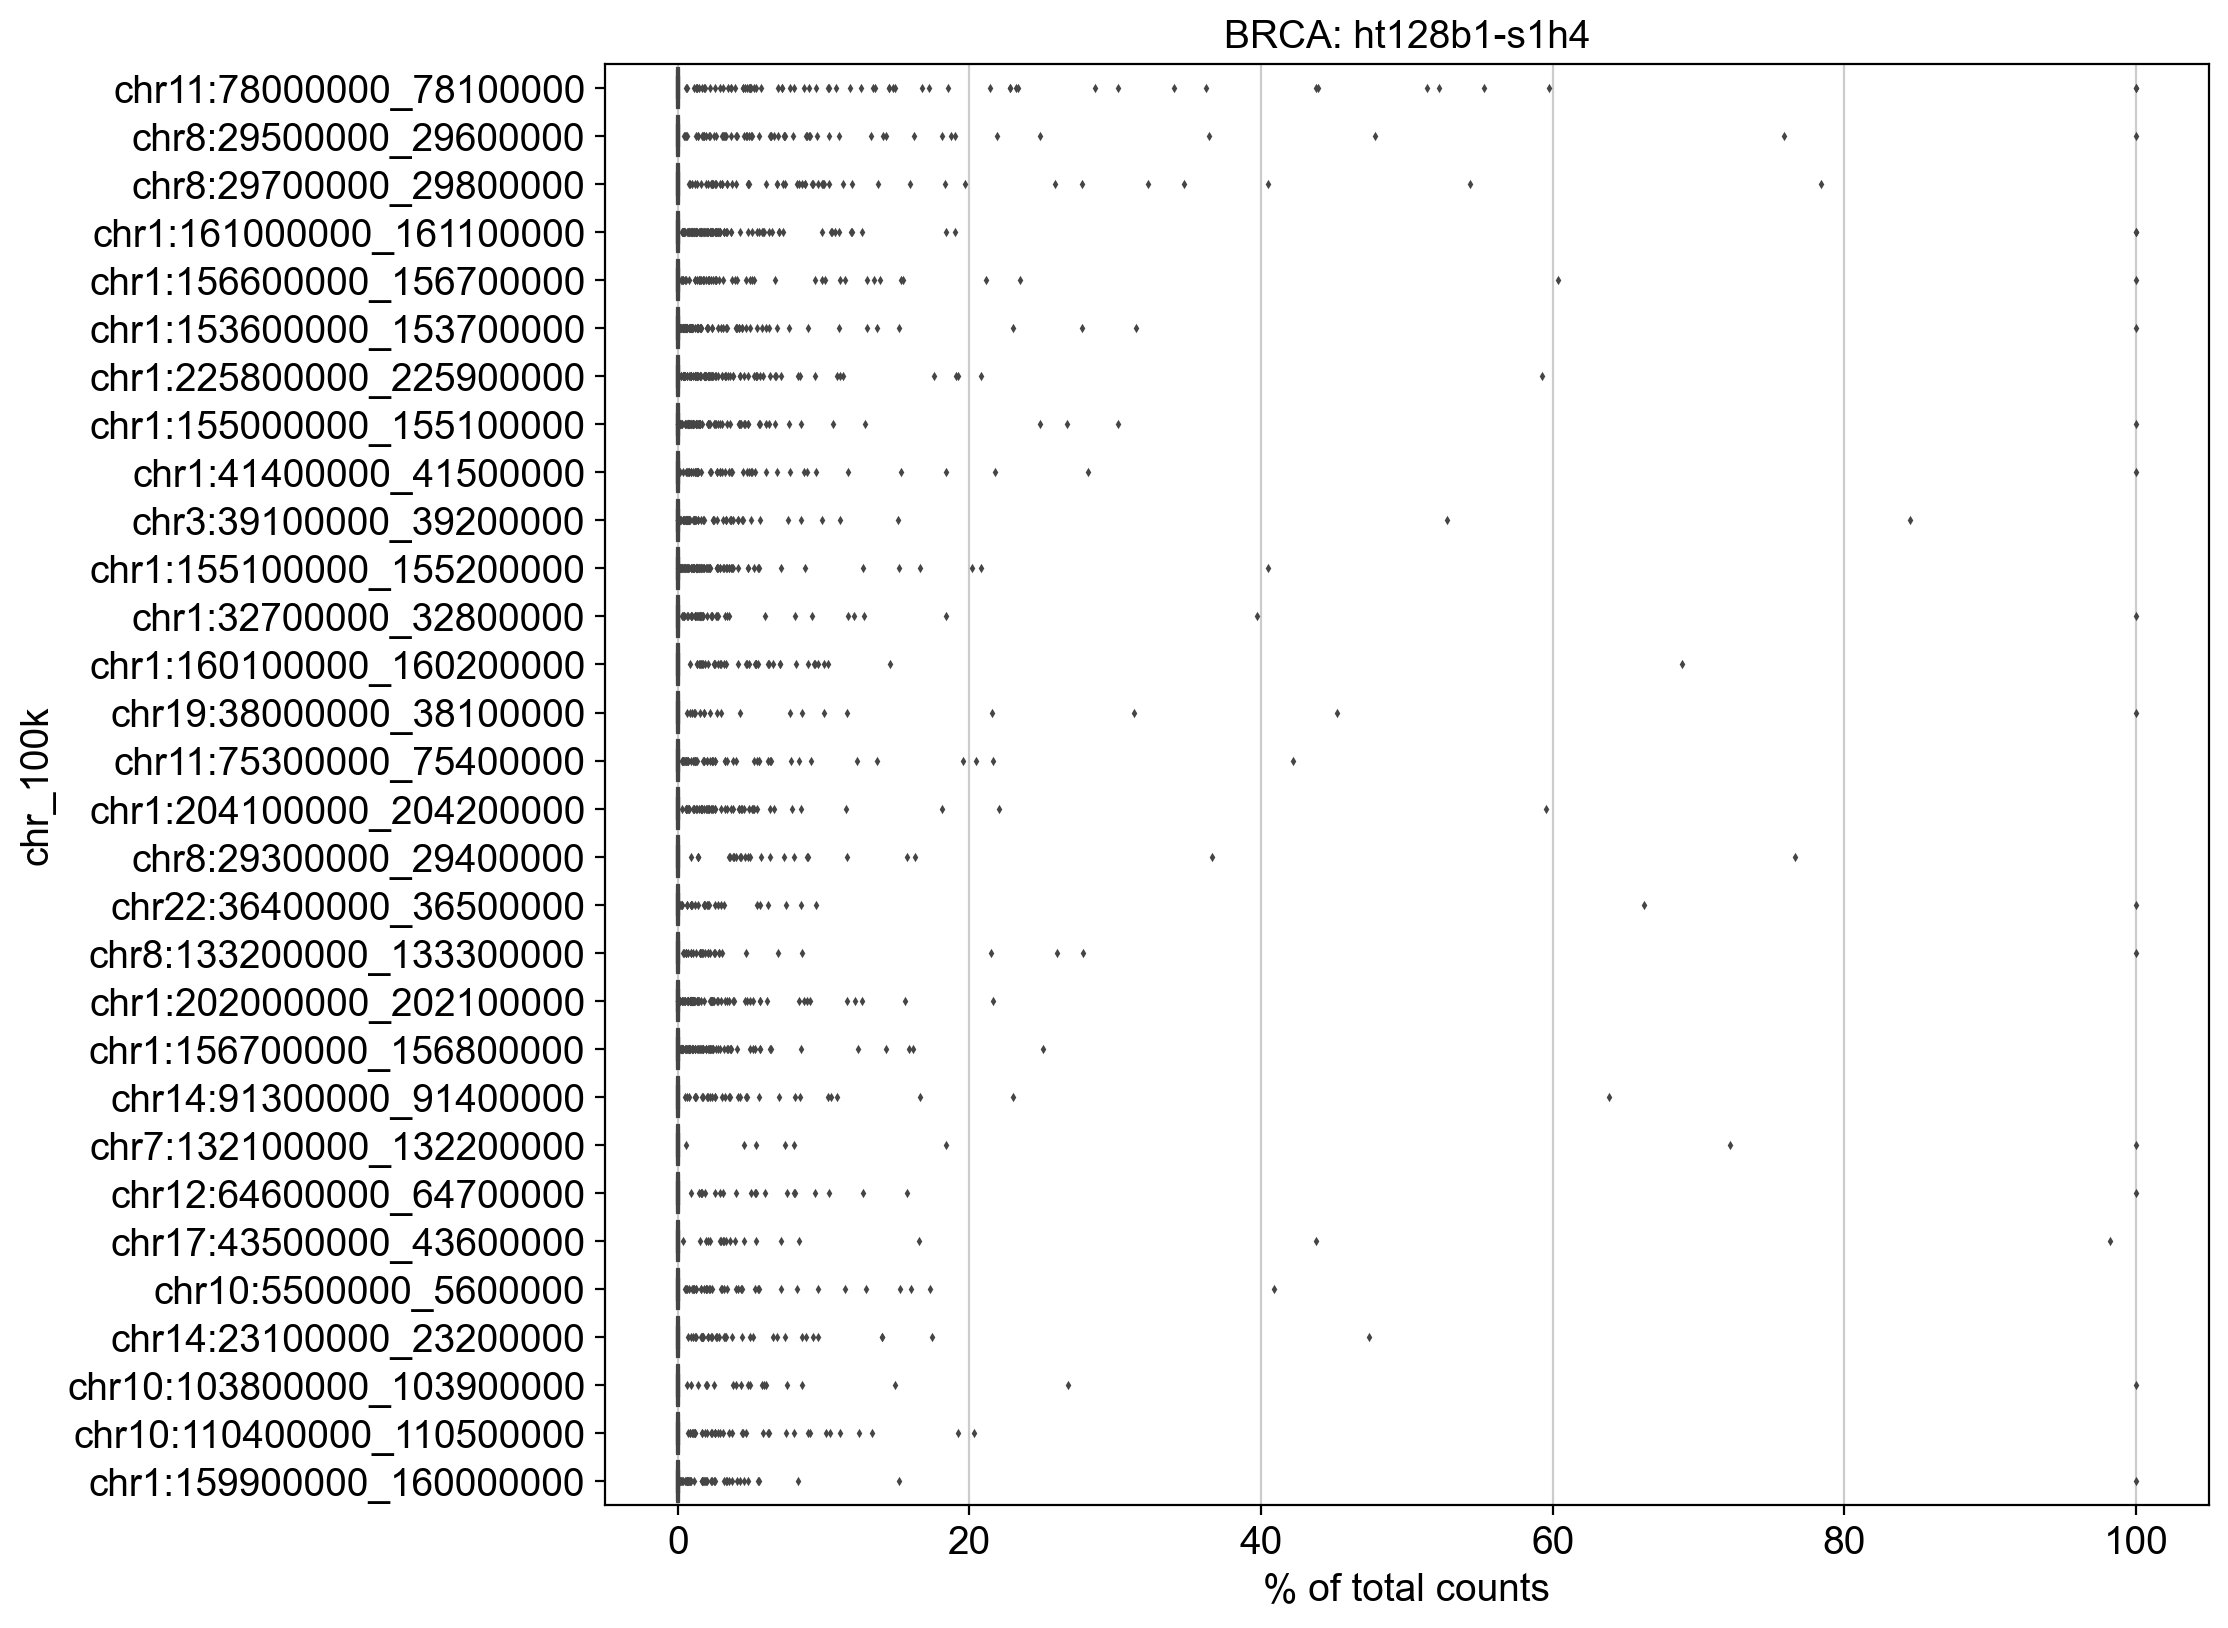

In [9]:
os.chdir(path)
print(os.getcwd())
#adata = sc.read(path+"/cellXecDNA_merge_df.matrix.h5ad")
#adata = sc.read(path+"/cellXecDNA_fi.matrix_01.h5ad")
#adata = sc.read(path+"/cellXecDNA_fi.matrix.h5ad")
adata = sc.read(path+"/cellXecDNA_fi.matrix_fi_background_mean3std.h5ad")
#lib_name = re.sub("(-fragments.tsv.gz|-atac_fragments.tsv.gz)$", "", path.split("htan_atac_merge")[1])
lib_name = str(cancer)+": "+str(sample)
if(os.path.exists(outpath) != True): os.makedirs(outpath)
os.chdir(outpath)
print(os.getcwd())

# 过滤低质量细胞
sc.pp.filter_cells(adata, min_genes=1)
sc.pp.filter_genes(adata, min_cells=1)

# f01
fig, ax = plt.subplots(figsize=(16, 13))
sc.pl.highest_expr_genes(adata, n_top=30, ax=ax, show=False)
plt.title(str(lib_name))
plt.tight_layout(pad=13.0)
fig.savefig("f01-highest_amplified_ecdna.pdf", bbox_inches='tight')
#plt.close(fig)

In [10]:
# calculate_qc_metrics
adata.var['chr19'] = adata.var_names.str.startswith('chr19') # annotate the group of chr19 ecdna_regions as 'chr19'
sc.pp.calculate_qc_metrics(adata, qc_vars=['chr19'], percent_top=None, log1p=False, inplace=True)
adata.obs["n_ecdna_regions"]=adata.obs["n_genes"]
adata.obs["total_coverages"]=adata.obs["total_counts"]
adata.obs["pct_coverages_chr19"]=adata.obs["pct_counts_chr19"]

# 标准化表达矩阵
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=1000)
#sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=np.inf, min_disp=0.5)
#sc.pp.highly_variable_genes(adata, min_mean=0.005125, max_mean=np.inf, min_disp=0.0125)

C:\Users\wangyuhang\AppData\Local\Temp\ipykernel_28592\4181474400.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(pad=13.0)


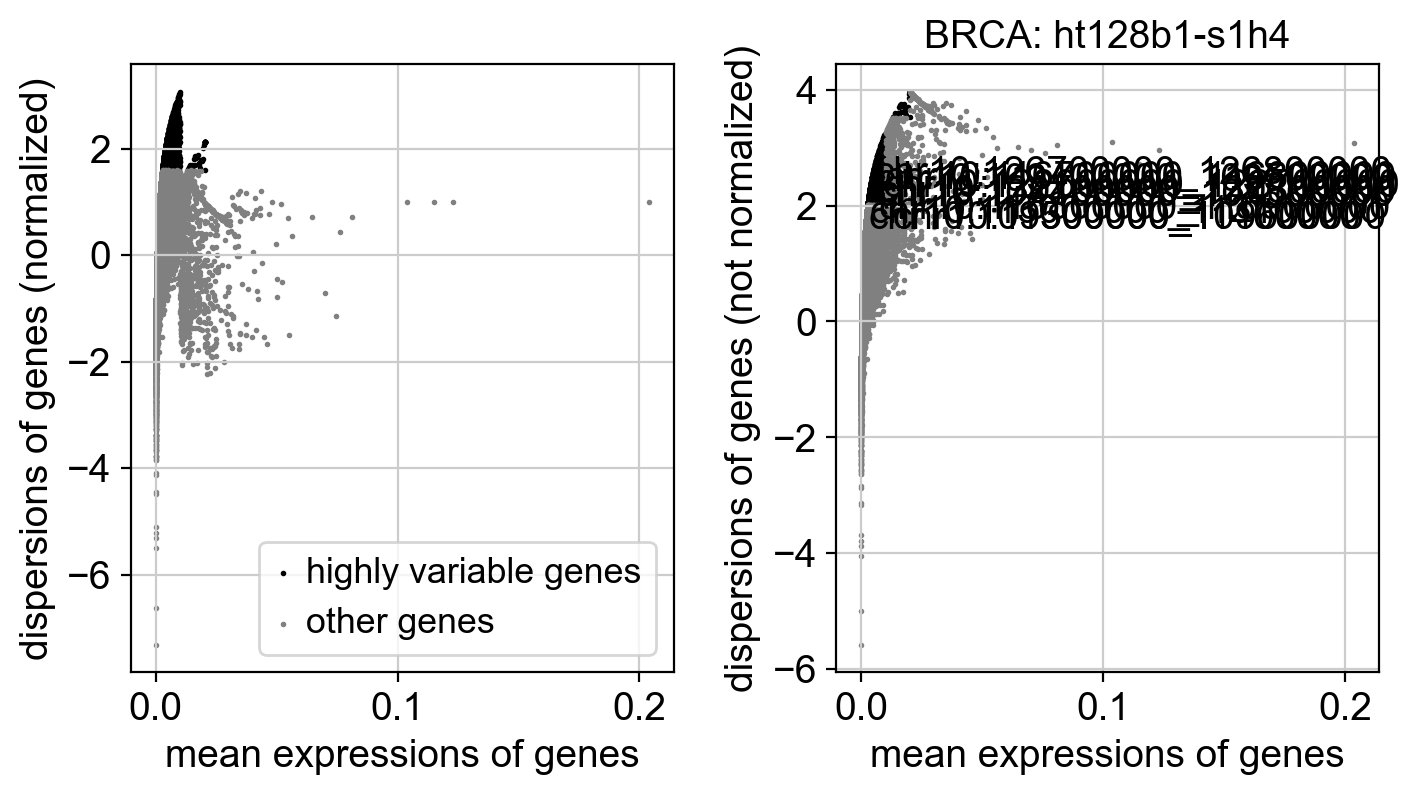

In [11]:
# 创建一个新的figure对象
#fig, ax = plt.subplots(figsize=(16, 16))
# 在这个figure对象上绘制图像
sc.pl.highly_variable_genes(adata, show=False)
# 获取高度可变基因的名字和坐标
hvg = adata.var[adata.var['highly_variable']]
for gene in hvg.index[:10]:
    x = hvg.loc[gene, 'means']
    y = hvg.loc[gene, 'dispersions_norm']
    plt.annotate(gene, (x, y))
    pass
plt.title(str(lib_name))
plt.tight_layout(pad=13.0)
# 保存图像为PDF文件
plt.savefig("f02-highly_variable_genes.pdf", bbox_inches='tight')
plt.close(fig)


In [12]:
adata

AnnData object with n_obs × n_vars = 2545 × 17850
    obs: 'barcode', 'sample_raw', 'cancer', 'sample', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_chr19', 'pct_counts_chr19', 'n_ecdna_regions', 'total_coverages', 'pct_coverages_chr19'
    var: 'chr_100k', 'n_cells', 'chr19', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'

In [13]:
adata.raw = adata
adata = adata[:, adata.var.highly_variable]
#sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])
sc.pp.scale(adata)
sc.pp.pca(adata, n_comps=50)
#sc.pl.pca_variance_ratio(adata, log=True)

In [14]:
adata

AnnData object with n_obs × n_vars = 2545 × 1000
    obs: 'barcode', 'sample_raw', 'cancer', 'sample', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_chr19', 'pct_counts_chr19', 'n_ecdna_regions', 'total_coverages', 'pct_coverages_chr19'
    var: 'chr_100k', 'n_cells', 'chr19', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [15]:
# cluster
sc.pp.neighbors(adata, n_pcs=30)  # 不建议用默认参数
sc.tl.umap(adata)

In [16]:
resolution_best = find_resolution(adata, n_clusters=3)
print("resolution_best: "+str(resolution_best))
sc.tl.leiden(adata, resolution=resolution_best)

resolution_best: 0.125


C:\Users\wangyuhang\AppData\Local\Temp\ipykernel_28592\2775469659.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=13)
C:\Users\wangyuhang\AppData\Local\Temp\ipykernel_28592\2775469659.py:35: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(pad=13)


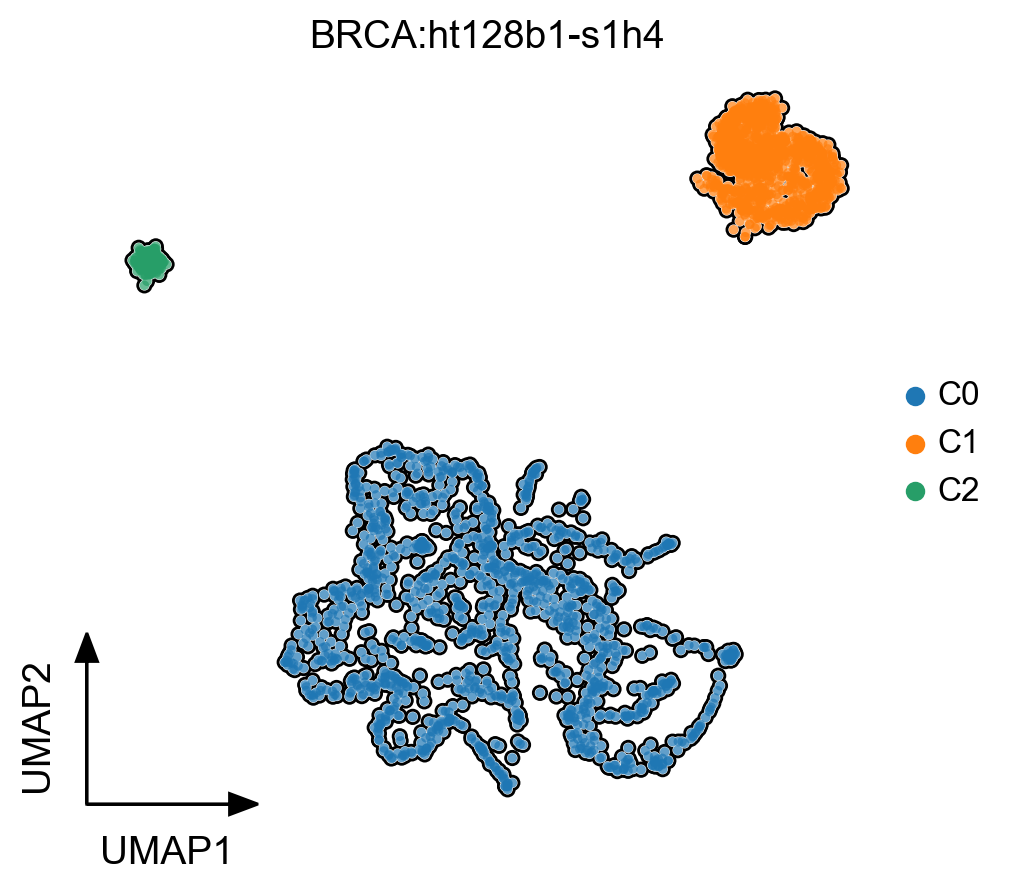

In [17]:
# create a dictionary to map cluster to annotation label
unique_leiden_values = adata.obs['leiden'].unique()
cluster2annotation = {value: f'C{value}' for value in unique_leiden_values}
# add a new `.obs` column called `cell type` by mapping clusters to annotation using pandas `map` function
adata.obs['cell_type'] = adata.obs['leiden'].map(cluster2annotation).astype('category')
# 生成颜色列表
from matplotlib.colors import to_hex
hex_colors = [to_hex(color) for color in sns.color_palette()]
cancer_pal = sns.color_palette(hex_colors)

# f02
fig, ax = plt.subplots(figsize=(5, 5))
sc.pl.umap(adata, 
           color='cell_type', 
           add_outline=True, 
           #legend_loc='on data',
           legend_loc='right margin',
           legend_fontsize=12, 
           legend_fontoutline=2,
           frameon=False,
           ax=ax,
           show=False,
           title=cancer+":"+sample, 
           palette=cancer_pal)
#plt.title(str(lib_name))
# 添加迷你的xy坐标轴
mini_ax = fig.add_axes([0.15, 0.15, 0.2, 0.2], frame_on=False)  # 在左下角添加一个新的坐标轴，不显示边框
mini_ax.set_xticks([])  # 不显示x轴的刻度
mini_ax.set_yticks([])  # 不显示y轴的刻度
mini_ax.set_xlabel('UMAP1')  # 设置x轴的名称
mini_ax.set_ylabel('UMAP2')  # 设置y轴的名称
# 添加箭头
mini_ax.arrow(0, 0, 1, 0, head_width=0.15, head_length=0.2, fc='k', ec='k')
mini_ax.arrow(0, 0, 0, 1, head_width=0.15, head_length=0.2, fc='k', ec='k')
plt.tight_layout(pad=13)
fig.savefig("f03-cell_clustering.pdf", bbox_inches='tight')

In [21]:
# Step 0：差异分析，明确指定使用 raw.X（必须先设置好 adata.raw）
sc.tl.rank_genes_groups(adata, groupby="cell_type", method="wilcoxon", use_raw=False)

C:\Users\wangyuhang\.conda\envs\inferecc\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
C:\Users\wangyuhang\.conda\envs\inferecc\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
C:\Users\wangyuhang\.conda\envs\inferecc\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(


In [23]:
adata

AnnData object with n_obs × n_vars = 2545 × 1000
    obs: 'barcode', 'sample_raw', 'cancer', 'sample', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_chr19', 'pct_counts_chr19', 'n_ecdna_regions', 'total_coverages', 'pct_coverages_chr19', 'leiden', 'cell_type'
    var: 'chr_100k', 'n_cells', 'chr19', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'cell_type_colors', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

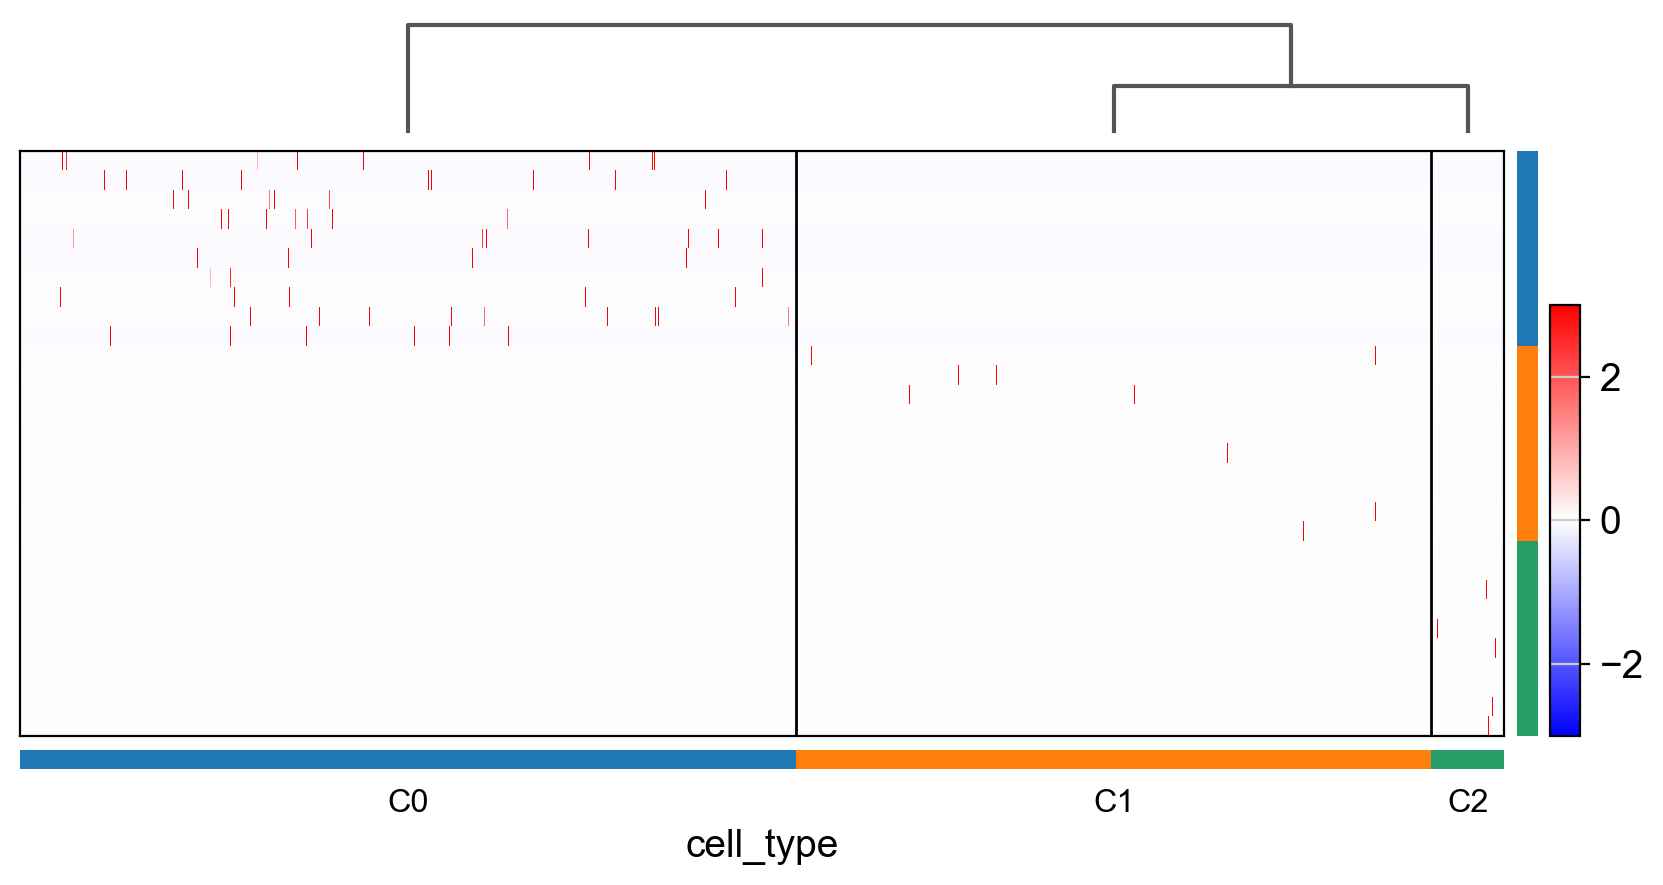

In [24]:
sc.pl.rank_genes_groups_heatmap(
    adata,
    n_genes=10,
    use_raw=False,
    swap_axes=True,
    show_gene_labels=False,
    vmin=-3,
    vmax=3,
    cmap="bwr",
)

C:\Users\wangyuhang\AppData\Local\Temp\ipykernel_18308\2562739430.py:53: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(pad=13.0)


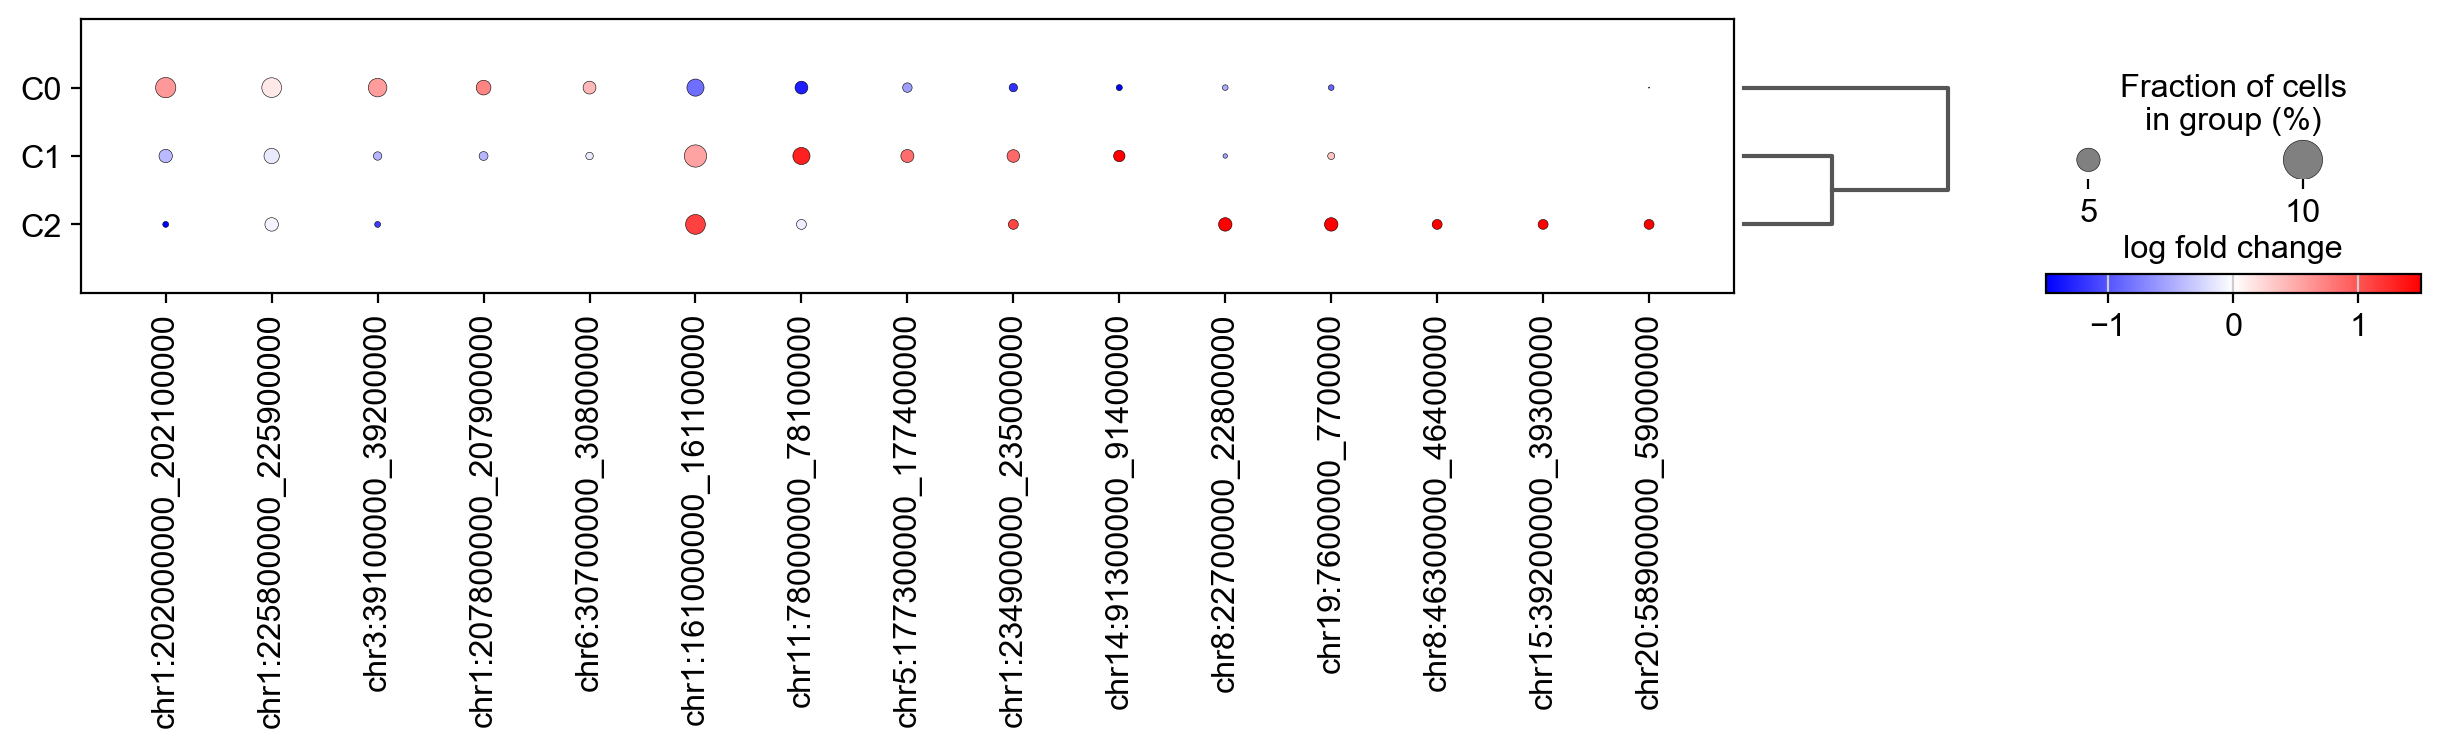

In [18]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 0：差异分析，明确指定使用 raw.X（必须先设置好 adata.raw）
sc.tl.rank_genes_groups(adata, groupby="cell_type", method="wilcoxon", use_raw=True)

# Step 1：计算表达比例（基于 adata.raw.X）
groups = adata.uns['rank_genes_groups']['names'].dtype.names
top_n = 5

# 创建比例矩阵：index 为 raw.var_names（即差异分析时使用的基因 ID）
expr_frac = pd.DataFrame(index=adata.raw.var_names)

for group in groups:
    adata_sub = adata[adata.obs['cell_type'] == group]
    Xraw = adata_sub.raw.X
    frac = (Xraw > 0).mean(axis=0).A1 if hasattr(Xraw, 'A1') else (Xraw > 0).mean(axis=0)
    expr_frac[group] = frac

# Step 2：获取各组 top_n 差异基因并按表达比例排序
top_genes_per_group = pd.DataFrame({
    group: adata.uns['rank_genes_groups']['names'][group][:top_n]
    for group in groups
})

# 合并所有 group 的基因，并按表达比例排序去重
final_genes = []
for group in groups:
    genes = top_genes_per_group[group]
    sorted_genes = expr_frac.loc[genes, group].sort_values(ascending=False).index.tolist()
    final_genes.extend(sorted_genes)

# 去重保留顺序
final_genes_unique = list(dict.fromkeys(final_genes))

# Step 3：绘图（指定 var_names，使用 raw.X）
fig, ax = plt.subplots(figsize=(15, 1.8))
sc.pl.rank_genes_groups_dotplot(
    adata,
    var_names=final_genes_unique,   # ✅ 必须是 raw.var_names 中的 ID
    groupby='cell_type',
    values_to_plot='logfoldchanges',
    min_logfoldchange=0.5,
    vmax=1.5, vmin=-1.5,
    figsize=(9, 1.8),
    ax=ax,
    cmap='bwr',
    use_raw=True,  # ✅ 必须启用，确保使用 .raw.X
    show=False
)
plt.tight_layout(pad=13.0)
fig.savefig("f04-bubble_sorted_by_expr.pdf", bbox_inches='tight')

C:\Users\wangyuhang\AppData\Local\Temp\ipykernel_28592\2430707692.py:53: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(pad=13.0)


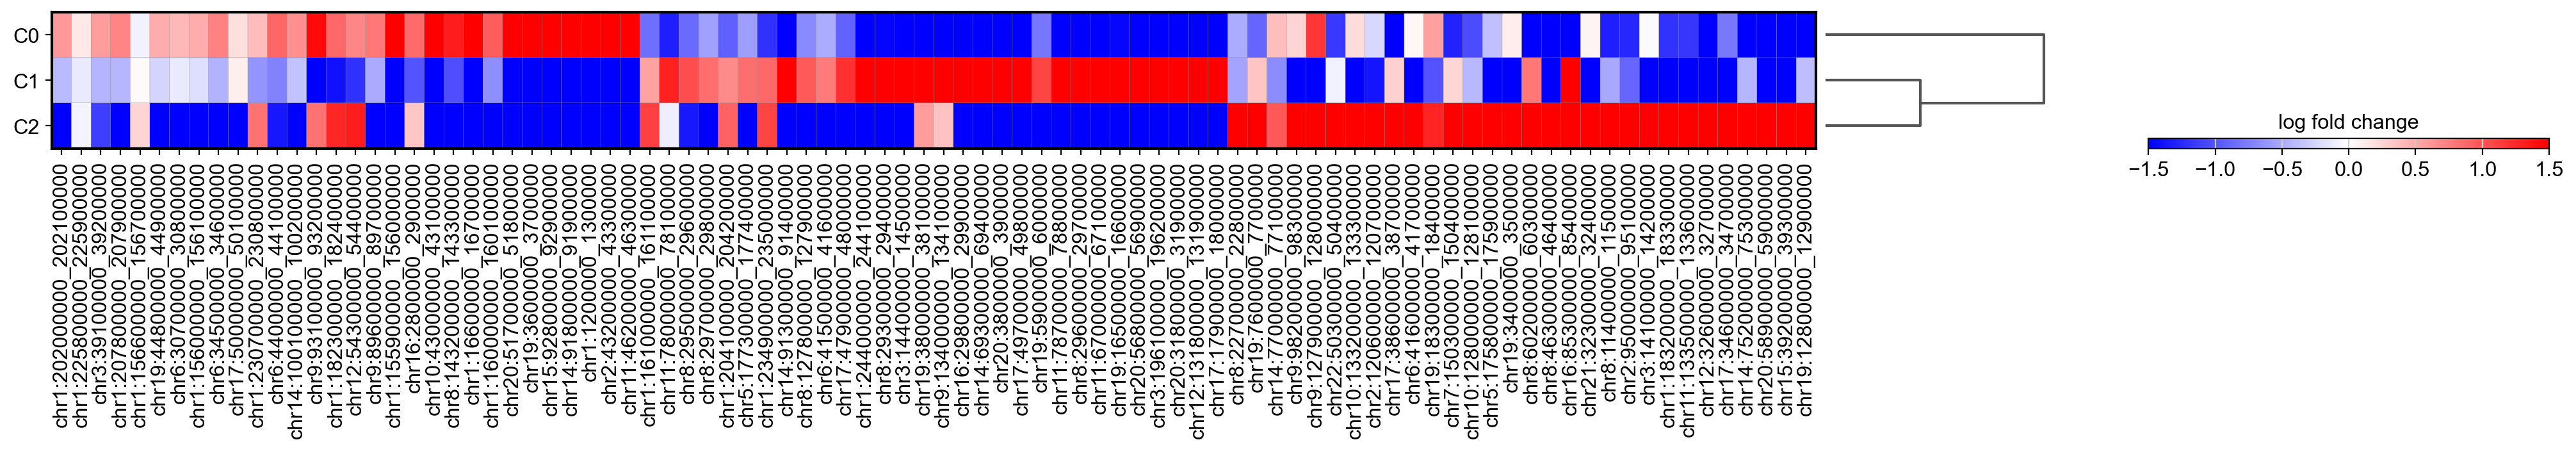

In [56]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 0：差异分析，明确指定使用 raw.X（必须先设置好 adata.raw）
sc.tl.rank_genes_groups(adata, groupby="cell_type", method="wilcoxon", use_raw=True)

# Step 1：计算表达比例（基于 adata.raw.X）
groups = adata.uns['rank_genes_groups']['names'].dtype.names
top_n = 30

# 创建比例矩阵：index 为 raw.var_names（即差异分析时使用的基因 ID）
expr_frac = pd.DataFrame(index=adata.raw.var_names)

for group in groups:
    adata_sub = adata[adata.obs['cell_type'] == group]
    Xraw = adata_sub.raw.X
    frac = (Xraw > 0).mean(axis=0).A1 if hasattr(Xraw, 'A1') else (Xraw > 0).mean(axis=0)
    expr_frac[group] = frac

# Step 2：获取各组 top_n 差异基因并按表达比例排序
top_genes_per_group = pd.DataFrame({
    group: adata.uns['rank_genes_groups']['names'][group][:top_n]
    for group in groups
})

# 合并所有 group 的基因，并按表达比例排序去重
final_genes = []
for group in groups:
    genes = top_genes_per_group[group]
    sorted_genes = expr_frac.loc[genes, group].sort_values(ascending=False).index.tolist()
    final_genes.extend(sorted_genes)

# 去重保留顺序
final_genes_unique_30 = list(dict.fromkeys(final_genes))

# Step 3：绘图（指定 var_names，使用 raw.X）
fig, ax = plt.subplots(figsize=(25, 1.4))
sc.pl.rank_genes_groups_matrixplot(
    adata,
    var_names=final_genes_unique_30,   # ✅ 必须是 raw.var_names 中的 ID
    groupby='cell_type',
    values_to_plot='logfoldchanges',
    min_logfoldchange=0.5,
    vmax=1.5, vmin=-1.5,
    figsize=(9, 1.8),
    ax=ax,
    cmap='bwr',
    use_raw=True,  # ✅ 必须启用，确保使用 .raw.X
    show=False
)
plt.tight_layout(pad=13.0)
fig.savefig("f04-bubble_sorted_by_expr_heatmap_30.pdf", bbox_inches='tight')

In [58]:
adata.uns['rank_genes_groups']

{'params': {'groupby': 'cell_type',
  'reference': 'rest',
  'method': 'wilcoxon',
  'use_raw': True,
  'layer': None,
  'corr_method': 'benjamini-hochberg'},
 'names': rec.array([('chr3:39100000_39200000', 'chr1:161000000_161100000', 'chr8:22700000_22800000'),
            ('chr1:202000000_202100000', 'chr14:91300000_91400000', 'chr8:46300000_46400000'),
            ('chr1:207800000_207900000', 'chr11:78000000_78100000', 'chr15:39200000_39300000'),
            ...,
            ('chr14:91300000_91400000', 'chr1:207800000_207900000', 'chr8:29700000_29800000'),
            ('chr11:78000000_78100000', 'chr1:202000000_202100000', 'chr1:202000000_202100000'),
            ('chr1:161000000_161100000', 'chr3:39100000_39200000', 'chr1:155100000_155200000')],
           dtype=[('C0', 'O'), ('C1', 'O'), ('C2', 'O')]),
 'scores': rec.array([( 1.0609453 ,  0.567513 ,  0.33003515),
            ( 0.8260618 ,  0.5091206,  0.30207452),
            ( 0.63835484,  0.4953267,  0.30207452), ...,
           

In [51]:
# 要删除的索引（从 0 开始计数）
indices_to_remove = [1, 4, 6, 7, 10,11,13,14,20,21,25,26]
# 构造新列表
final_genes_unique2 = [x for i, x in enumerate(final_genes_unique) if i not in indices_to_remove]
final_genes_unique2

['chr1:202000000_202100000',
 'chr3:39100000_39200000',
 'chr1:207800000_207900000',
 'chr6:34500000_34600000',
 'chr19:3600000_3700000',
 'chr15:92800000_92900000',
 'chr8:29500000_29600000',
 'chr14:91300000_91400000',
 'chr8:29300000_29400000',
 'chr1:244000000_244100000',
 'chr3:14400000_14500000',
 'chr14:69300000_69400000',
 'chr8:46300000_46400000',
 'chr15:39200000_39300000',
 'chr20:58900000_59000000',
 'chr12:32600000_32700000',
 'chr11:133500000_133600000',
 'chr1:183200000_183300000']

C:\Users\wangyuhang\AppData\Local\Temp\ipykernel_28592\3319110147.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(pad=13.0)


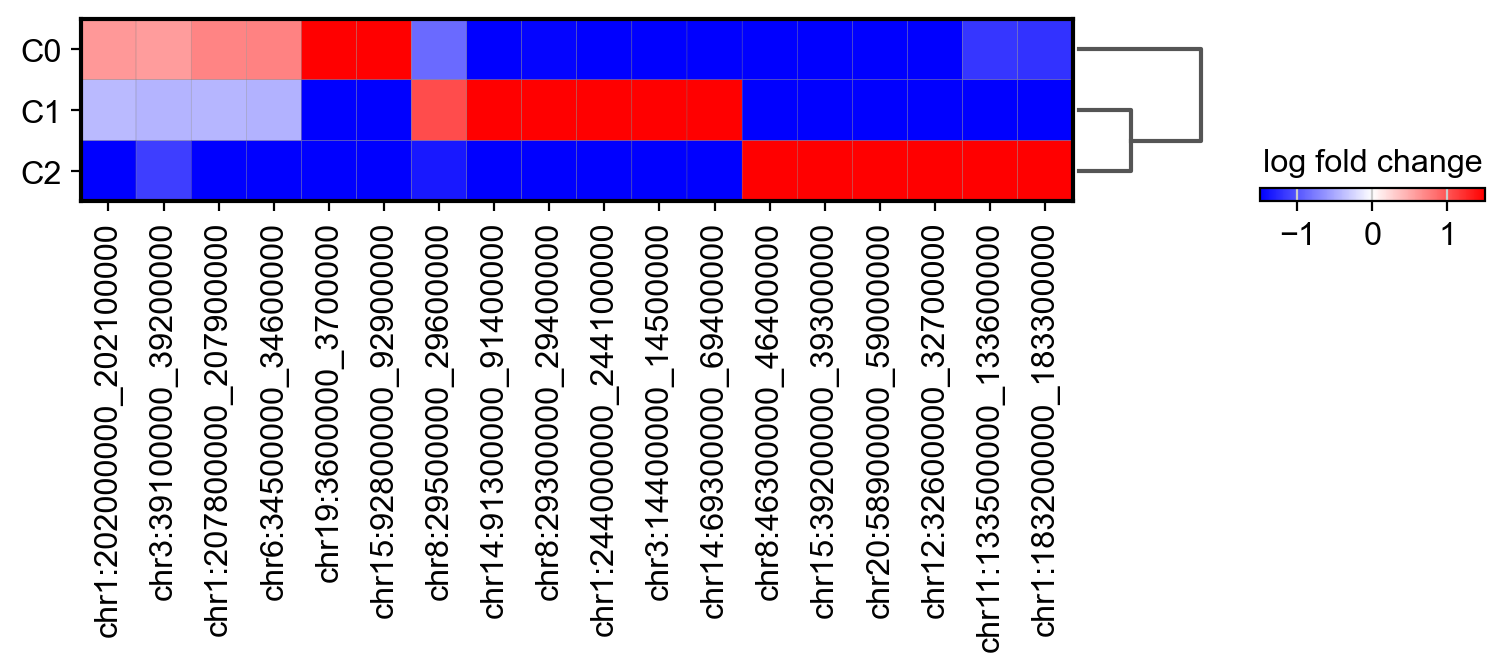

In [55]:
# Step 3：绘图（指定 var_names，使用 raw.X）
fig, ax = plt.subplots(figsize=(9, 1.2))
sc.pl.rank_genes_groups_matrixplot(
    adata,
    var_names=final_genes_unique2,   # ✅ 必须是 raw.var_names 中的 ID
    groupby='cell_type',
    values_to_plot='logfoldchanges',
    min_logfoldchange=0.5,
    vmax=1.5, vmin=-1.5,
    figsize=(9, 1.8),
    ax=ax,
    cmap='bwr',
    use_raw=True,  # ✅ 必须启用，确保使用 .raw.X
    show=False
)
plt.tight_layout(pad=13.0)
fig.savefig("f04-bubble_sorted_by_expr_heatmap_2_2.pdf", bbox_inches='tight')

C:\Users\wangyuhang\AppData\Local\Temp\ipykernel_28592\4023670056.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(pad=13.0)


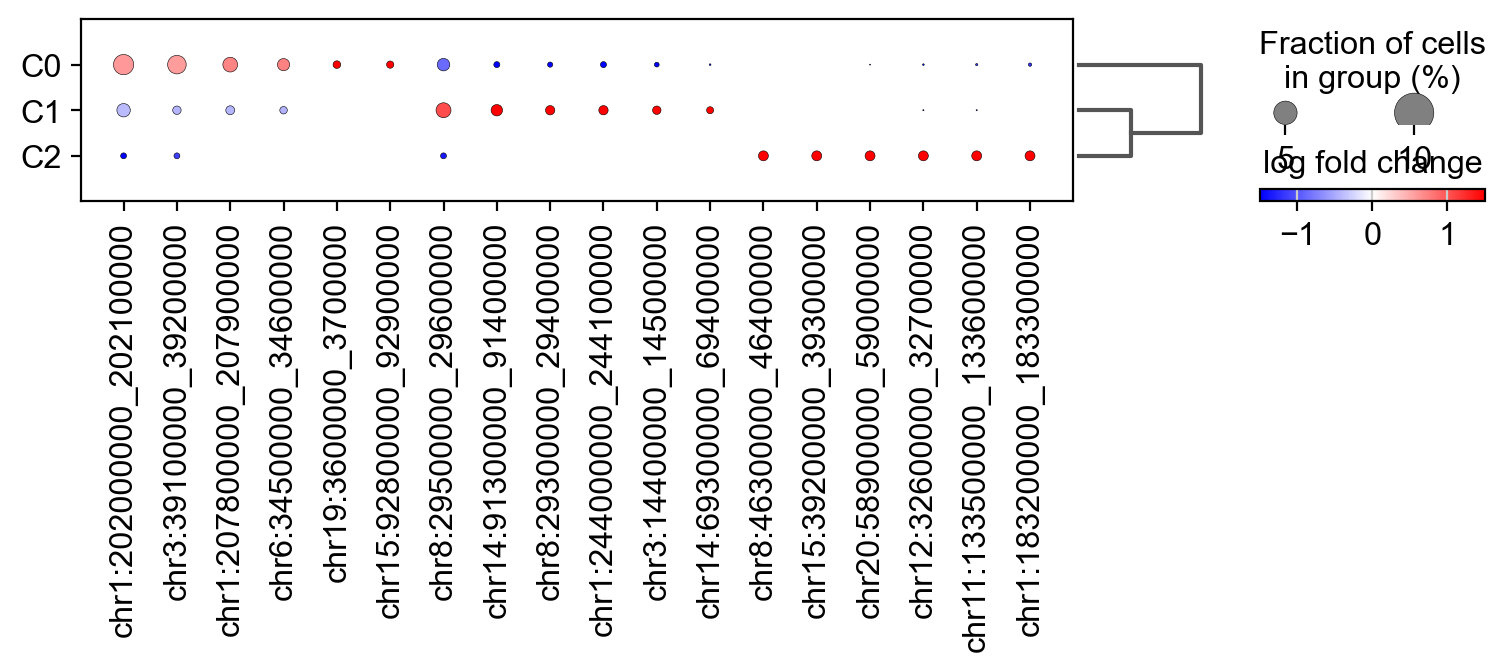

In [67]:
# Step 3：绘图（指定 var_names，使用 raw.X）
fig, ax = plt.subplots(figsize=(9, 1.2))
sc.pl.rank_genes_groups_dotplot(
    adata,
    var_names=final_genes_unique2,   # ✅ 必须是 raw.var_names 中的 ID
    groupby='cell_type',
    values_to_plot='logfoldchanges',
    min_logfoldchange=0.5,
    vmax=1.5, vmin=-1.5,
    figsize=(9, 1.8),
    ax=ax,
    cmap='bwr',
    use_raw=True,  # ✅ 必须启用，确保使用 .raw.X
    show=False
)
plt.tight_layout(pad=13.0)
fig.savefig("f04-bubble_sorted_by_expr_heatmap_2_3.pdf", bbox_inches='tight')

                            gene     logfc  pval_adj
0         chr3:39100000_39200000  0.584173  0.997892
1       chr1:202000000_202100000  0.602287  0.997892
2       chr1:207800000_207900000  0.719963  0.997892
3         chr6:30700000_30800000  0.410242  0.997892
4       chr1:225800000_225900000  0.132716  0.997892
...                          ...       ...       ...
17259      chr17:3500000_3600000  0.177083  0.997892
17262      chr12:6100000_6200000  0.401589  0.997892
17384  chr14:102400000_102500000  0.201199  0.997892
17391   chr1:206600000_206700000  0.162076  0.997892
17654   chr9:127700000_127800000  0.311686  0.997892

[11104 rows x 3 columns]
                           gene     logfc  pval_adj
0      chr1:161000000_161100000  0.549052  0.999956
1       chr14:91300000_91400000  2.013076  0.999956
2       chr11:78000000_78100000  1.308062  0.999956
3      chr5:177300000_177400000  0.852525  0.999956
4      chr1:234900000_235000000  0.885800  0.999956
...                       

C:\Users\wangyuhang\AppData\Local\Temp\ipykernel_28592\1936113704.py:77: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(pad=13.0)


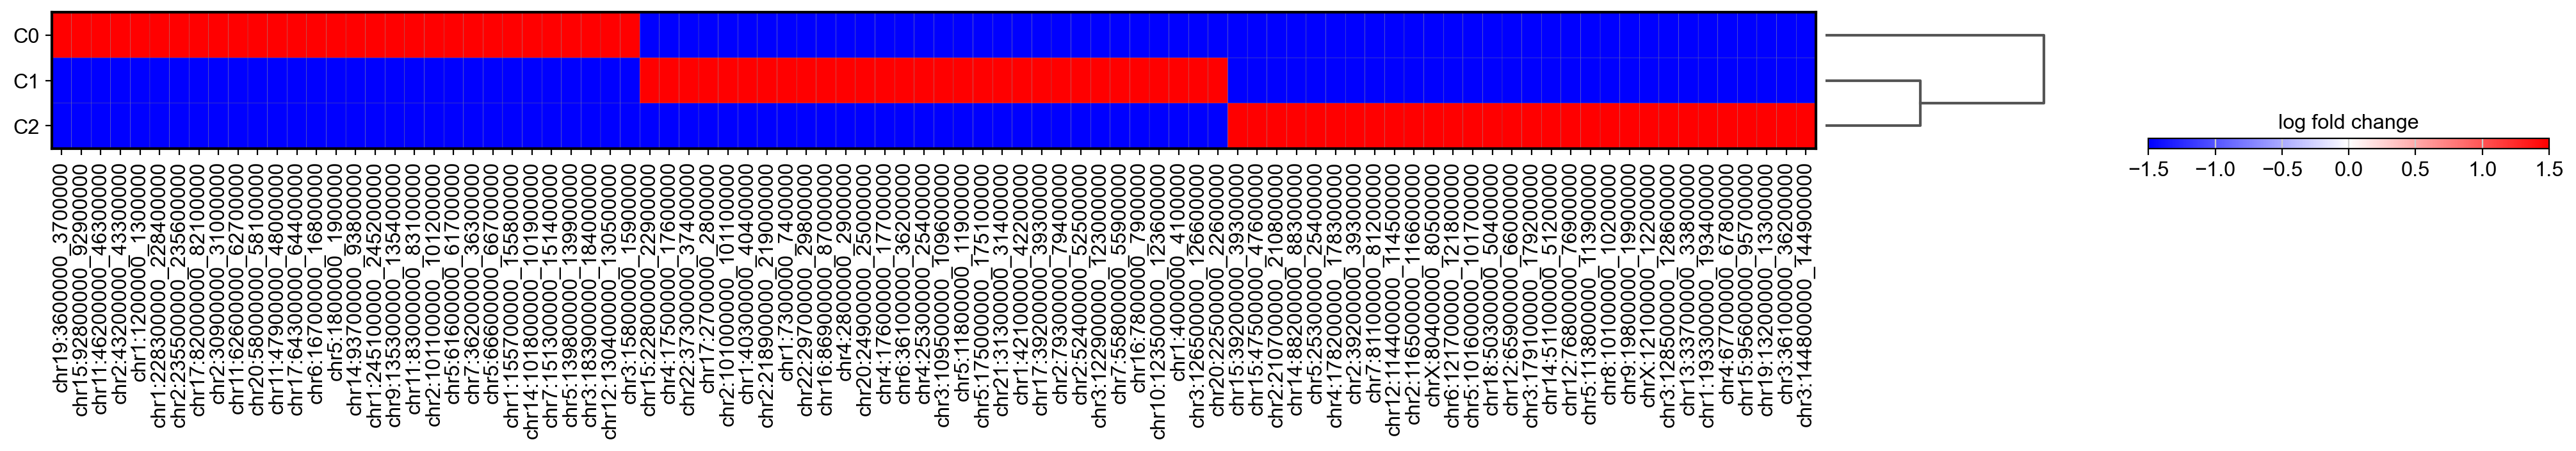

In [65]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 0：差异分析，明确指定使用 raw.X（必须先设置好 adata.raw）
sc.tl.rank_genes_groups(adata, groupby="cell_type", method="wilcoxon", use_raw=True)

# Step 1：计算表达比例（基于 adata.raw.X）
groups = adata.uns['rank_genes_groups']['names'].dtype.names
top_n = 30

# 创建比例矩阵：index 为 raw.var_names（即差异分析时使用的基因 ID）
expr_frac = pd.DataFrame(index=adata.raw.var_names)

for group in groups:
    adata_sub = adata[adata.obs['cell_type'] == group]
    Xraw = adata_sub.raw.X
    frac = (Xraw > 0).mean(axis=0).A1 if hasattr(Xraw, 'A1') else (Xraw > 0).mean(axis=0)
    expr_frac[group] = frac

# Step 2：按 logFC 和 p 值筛选后，获取 top_n 基因并按表达比例排序
top_genes_per_group = {}

for group in groups:
    # 获取基因名、logFC 和 p 值
    gene_names = adata.uns['rank_genes_groups']['names'][group]
    logfc_vals = adata.uns['rank_genes_groups']['logfoldchanges'][group]
    pvals_adj_vals = adata.uns['rank_genes_groups']['pvals_adj'][group]
    
    # 构建 DataFrame 便于过滤和排序
    df = pd.DataFrame({
        "gene": gene_names,
        "logfc": logfc_vals,
        "pval_adj": pvals_adj_vals
    })
    #print(df)
    # 过滤条件：logFC > 0 且 p 值显著
    #df = df[(df["logfc"] > 0) & (df["pval_adj"] < 0.05)]
    df = df[(df["logfc"] > 0)]
    print(df)

    # 按 logFC 降序排序，选前 top_n
    top_genes = df.sort_values(by="logfc", ascending=False).head(top_n)["gene"].tolist()

    # 存储
    top_genes_per_group[group] = top_genes

# 转为 DataFrame 便于后续遍历
top_genes_per_group = pd.DataFrame(top_genes_per_group)

# 合并所有组的 top_n 基因列表，按表达比例排序并去重
final_genes = []
for group in groups:
    genes = top_genes_per_group[group]
    sorted_genes = expr_frac.loc[genes, group].sort_values(ascending=False).index.tolist()
    final_genes.extend(sorted_genes)

# 去重保留顺序
final_genes_unique_30 = list(dict.fromkeys(final_genes))

# Step 3：绘图（指定 var_names，使用 raw.X）
fig, ax = plt.subplots(figsize=(25, 1.4))
sc.pl.rank_genes_groups_matrixplot(
    adata,
    var_names=final_genes_unique_30,   # ✅ 必须是 raw.var_names 中的 ID
    groupby='cell_type',
    values_to_plot='logfoldchanges',
    min_logfoldchange=0.5,
    vmax=1.5, vmin=-1.5,
    figsize=(9, 1.8),
    ax=ax,
    cmap='bwr',
    use_raw=True,  # ✅ 必须启用，确保使用 .raw.X
    show=False
)
plt.tight_layout(pad=13.0)
fig.savefig("f04-bubble_sorted_by_expr_heatmap_30_2.pdf", bbox_inches='tight')

C:\Users\wangyuhang\AppData\Local\Temp\ipykernel_28592\3092043998.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(pad=13.0)


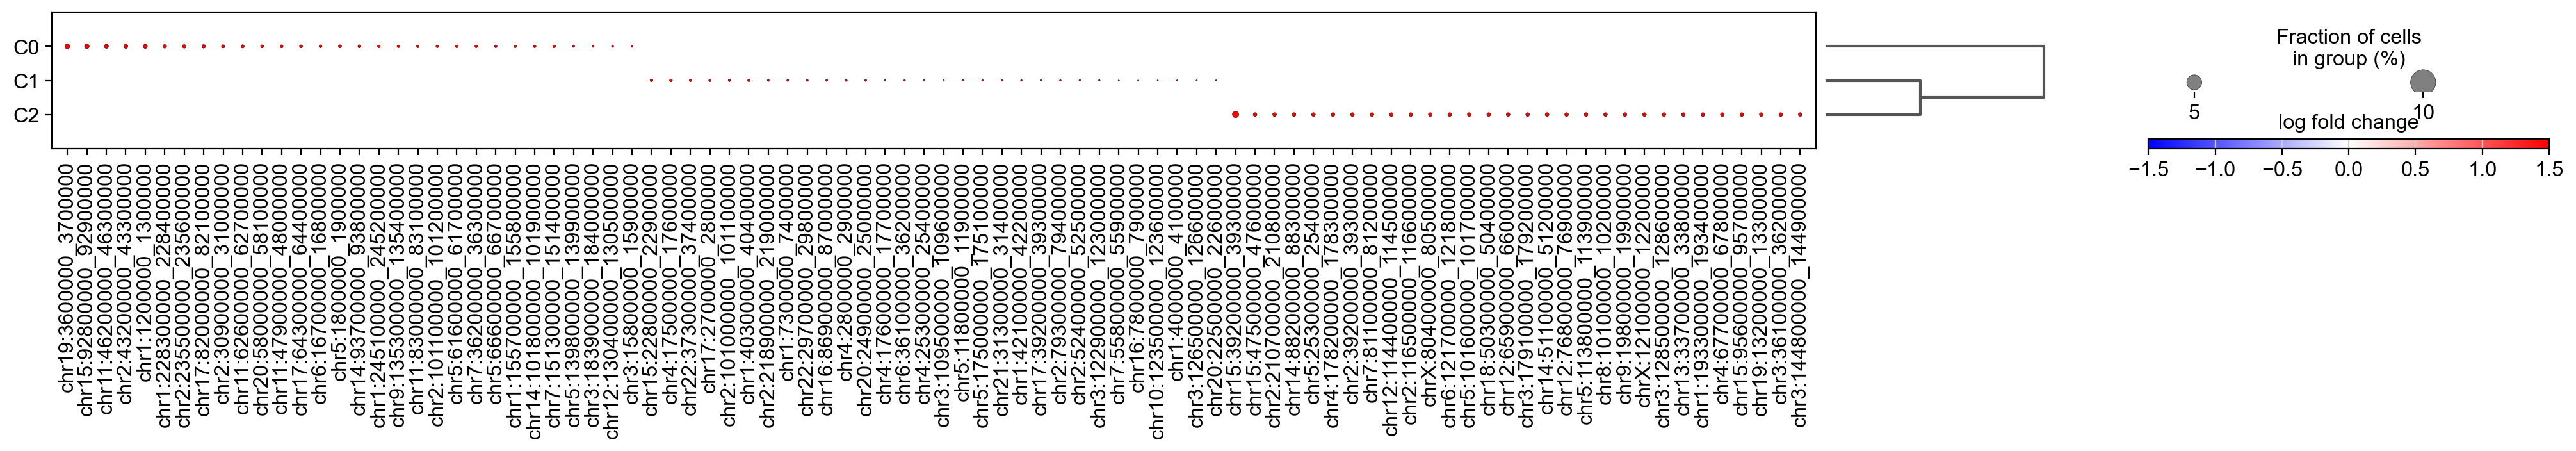

In [66]:
# Step 3：绘图（指定 var_names，使用 raw.X）
fig, ax = plt.subplots(figsize=(12, 1.4))
sc.pl.rank_genes_groups_dotplot(
    adata,
    var_names=final_genes_unique_30,   # ✅ 必须是 raw.var_names 中的 ID
    groupby='cell_type',
    values_to_plot='logfoldchanges',
    min_logfoldchange=0.5,
    vmax=1.5, vmin=-1.5,
    figsize=(9, 1.8),
    ax=ax,
    cmap='bwr',
    use_raw=True,  # ✅ 必须启用，确保使用 .raw.X
    show=False
)
plt.tight_layout(pad=13.0)
fig.savefig("f04-bubble_sorted_by_expr_heatmap_30_3.pdf", bbox_inches='tight')

C:\Users\wangyuhang\AppData\Local\Temp\ipykernel_28592\3939422644.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(pad=13.0)


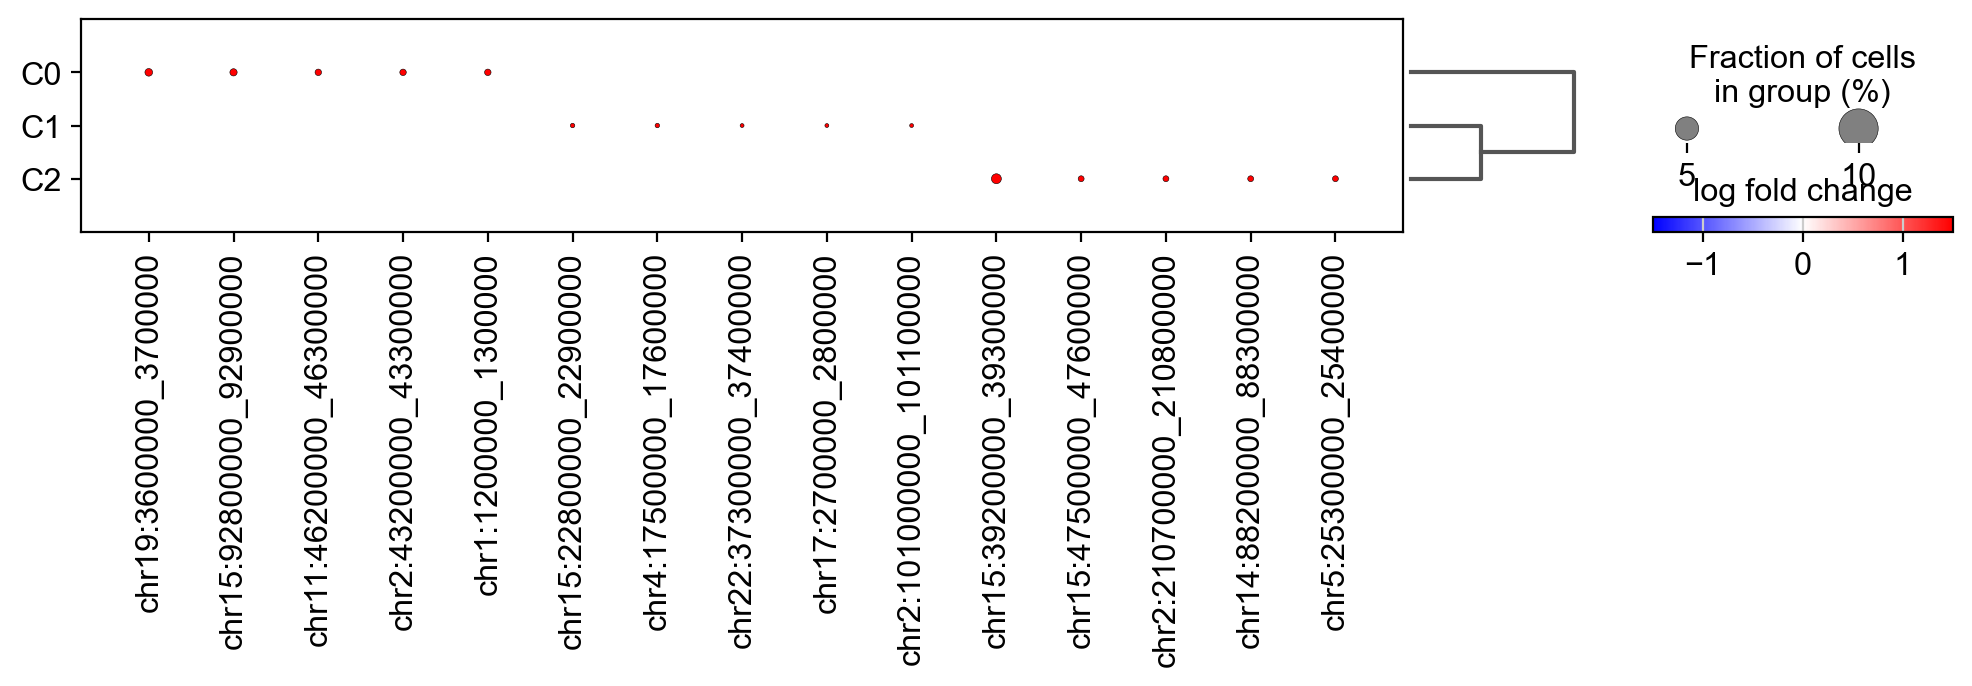

In [71]:
indices_to_remove = list(range(5, 30)) + list(range(35, 60)) + list(range(65, 90))
# 构造新列表
final_genes_unique_30_5 = [x for i, x in enumerate(final_genes_unique_30) if i not in indices_to_remove]
final_genes_unique_30_5

# Step 3：绘图（指定 var_names，使用 raw.X）
fig, ax = plt.subplots(figsize=(12, 1.4))
sc.pl.rank_genes_groups_dotplot(
    adata,
    var_names=final_genes_unique_30_5,   # ✅ 必须是 raw.var_names 中的 ID
    groupby='cell_type',
    values_to_plot='logfoldchanges',
    min_logfoldchange=0.5,
    vmax=1.5, vmin=-1.5,
    figsize=(9, 1.8),
    ax=ax,
    cmap='bwr',
    use_raw=True,  # ✅ 必须启用，确保使用 .raw.X
    show=False
)
plt.tight_layout(pad=13.0)
fig.savefig("f04-bubble_sorted_by_expr_heatmap_30_5_dotplot.pdf", bbox_inches='tight')

C:\Users\wangyuhang\AppData\Local\Temp\ipykernel_28592\2024110853.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(pad=13.0)


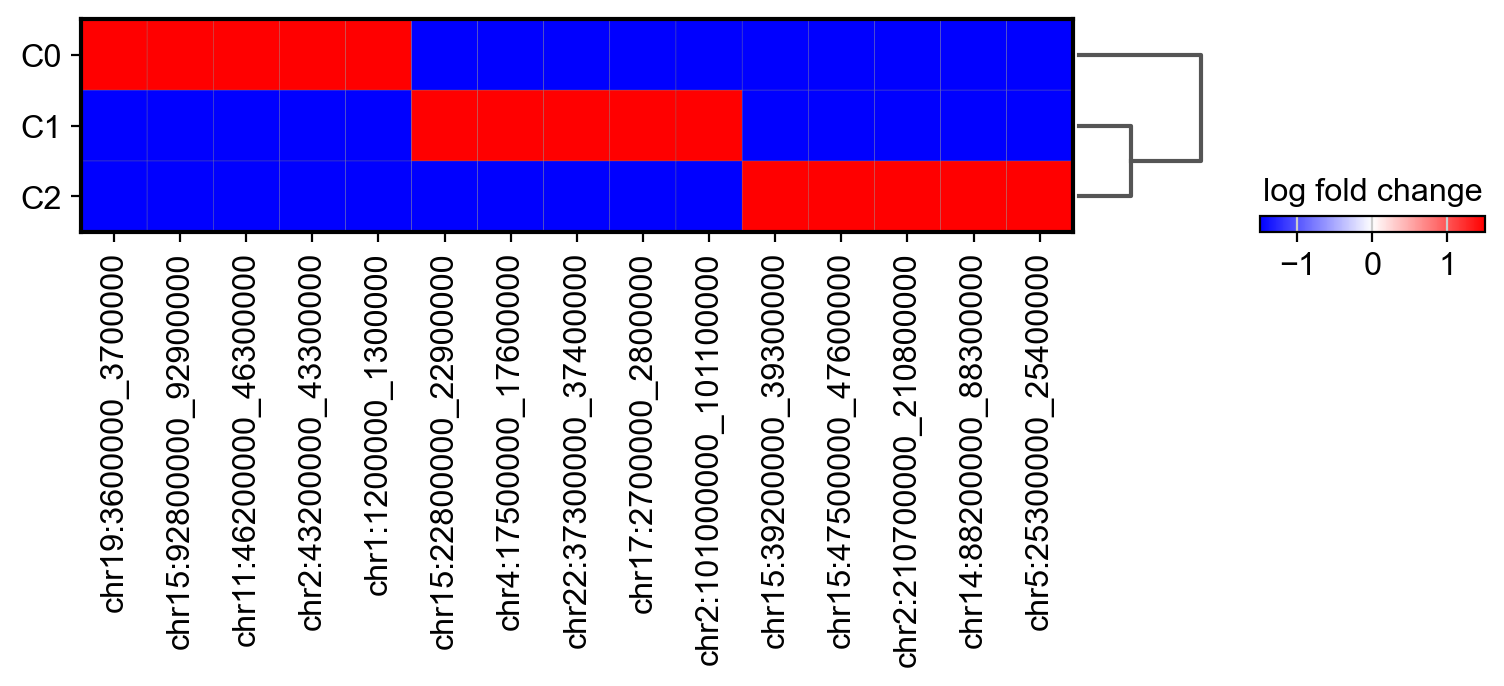

In [73]:
# Step 3：绘图（指定 var_names，使用 raw.X）
fig, ax = plt.subplots(figsize=(9, 1.4))
sc.pl.rank_genes_groups_matrixplot(
    adata,
    var_names=final_genes_unique_30_5,   # ✅ 必须是 raw.var_names 中的 ID
    groupby='cell_type',
    values_to_plot='logfoldchanges',
    min_logfoldchange=0.5,
    vmax=1.5, vmin=-1.5,
    figsize=(9, 1.8),
    ax=ax,
    cmap='bwr',
    use_raw=True,  # ✅ 必须启用，确保使用 .raw.X
    show=False
)
plt.tight_layout(pad=13.0)
fig.savefig("f04-bubble_sorted_by_expr_heatmap_30_5_matrixplot.pdf", bbox_inches='tight')

C:\Users\wangyuhang\AppData\Local\Temp\ipykernel_28592\3055460202.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(pad=13.0)


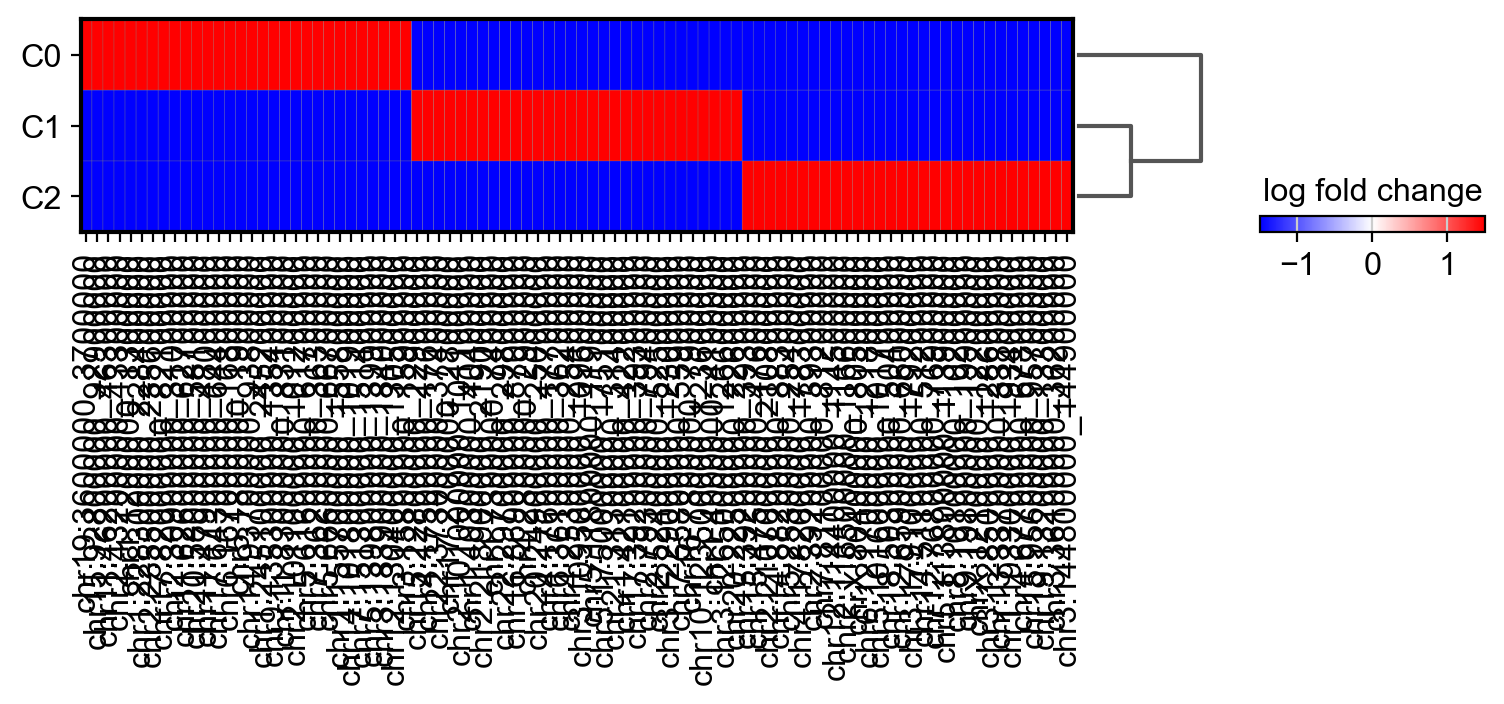

In [74]:
# Step 3：绘图（指定 var_names，使用 raw.X）
fig, ax = plt.subplots(figsize=(9, 1.4))
sc.pl.rank_genes_groups_matrixplot(
    adata,
    var_names=final_genes_unique_30,   # ✅ 必须是 raw.var_names 中的 ID
    groupby='cell_type',
    values_to_plot='logfoldchanges',
    min_logfoldchange=0.5,
    vmax=1.5, vmin=-1.5,
    figsize=(9, 1.8),
    ax=ax,
    cmap='bwr',
    use_raw=True,  # ✅ 必须启用，确保使用 .raw.X
    show=False
)
plt.tight_layout(pad=13.0)
fig.savefig("f04-bubble_sorted_by_expr_heatmap_30_5_matrixplot.pdf", bbox_inches='tight')

In [ ]:
########## 全部 

In [87]:
sc.tl.rank_genes_groups(adata, groupby="cell_type", method="wilcoxon", use_raw=True, pts=True)

rank_results = adata.uns['rank_genes_groups']
 
all_groups_results = pd.DataFrame()
 
group_labels = adata.obs[rank_results['params']['groupby']].unique()
for group_label in group_labels:
    group_df = sc.get.rank_genes_groups_df(adata, group=group_label)
    group_df = group_df.sort_values(by="scores", ascending=False)
    #group_df = group_df[abs(group_df['logfoldchanges']) >= 0.25]
    pts = adata.uns['rank_genes_groups']['pts'][group_label]
    selected_genes = pts[pts >= 0].index.tolist()
    group_df = group_df[group_df['names'].isin(selected_genes)]
    group_df['group'] = group_label
    all_groups_results = pd.concat([all_groups_results, group_df], ignore_index=True)
 
#all_groups_results.to_csv(f'f04-00-rank_genes_groups_hvg.csv', index=False)

In [209]:
dfa = all_groups_results[all_groups_results["logfoldchanges"]>=15]
dfa

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,group
5,chr19:3600000_3700000,0.491748,22.789022,0.622897,0.997892,0.011270,0.0,C0
9,chr15:92800000_92900000,0.458965,22.921587,0.646259,0.997892,0.010518,0.0,C0
19,chr1:1200000_1300000,0.393399,22.531679,0.694025,0.997892,0.009016,0.0,C0
20,chr2:43200000_43300000,0.393399,22.530342,0.694025,0.997892,0.009016,0.0,C0
21,chr11:46200000_46300000,0.393399,22.495768,0.694025,0.997892,0.009016,0.0,C0
...,...,...,...,...,...,...,...,...
35960,chr12:76800000_76900000,0.151037,24.867147,0.879946,0.995113,0.008000,0.0,C2
35961,chr3:162800000_162900000,0.151037,24.040565,0.879946,0.995113,0.008000,0.0,C2
35962,chr9:7200000_7300000,0.151037,24.506758,0.879946,0.995113,0.008000,0.0,C2
35963,chr13:104800000_104900000,0.151037,23.771574,0.879946,0.995113,0.008000,0.0,C2


In [210]:
dfa.group.value_counts()

C0    8137
C1    2589
C2     220
Name: group, dtype: int64

In [211]:
# 假设 logfoldchanges 是数值型列
dfa = (
    dfa
    .groupby("group", group_keys=False)
    .apply(lambda x: x.nlargest(100, "scores"))
)
dfa.group.value_counts()

C0    100
C1    100
C2    100
Name: group, dtype: int64

In [212]:
dfa["chr_raw"] = dfa["names"]

df_ecdna = dfa.copy()
df_ecdna_gene = genebody_region(df_fragments=df_ecdna,species="hg38")
df_ecdna_gene['oncogene'] = df_ecdna_gene['genebody_region_gene'].apply(custom_transform)
df_ecdna_gene

species value: hg38


,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,group,chr_raw,genebody_region,genebody_region_gene,oncogene
5,chr19:3600000_3700000,0.491748,22.789022,0.622897,0.997892,0.011270,0.0,C0,chr19:3600000_3700000,5,"[TBXA2R, CACTIN-AS1, CACTIN, PIP5K1C, AC004637.1]",[]
9,chr15:92800000_92900000,0.458965,22.921587,0.646259,0.997892,0.010518,0.0,C0,chr15:92800000_92900000,6,"[FAM174B, CTD-2313J17.1, CTD-2313J17.6, CTD-23...",[]
19,chr1:1200000_1300000,0.393399,22.531679,0.694025,0.997892,0.009016,0.0,C0,chr1:1200000_1300000,11,"[TNFRSF18, TNFRSF4, SDF4, B3GALT6, FAM132A, RP...",[]
20,chr2:43200000_43300000,0.393399,22.530342,0.694025,0.997892,0.009016,0.0,C0,chr2:43200000_43300000,4,"[ZFP36L2, LINC01126, AC010883.5, THADA]",[]
21,chr11:46200000_46300000,0.393399,22.495768,0.694025,0.997892,0.009016,0.0,C0,chr11:46200000_46300000,4,"[RP11-702F3.4, CTD-2589M5.5, CTD-2589M5.4, CRE...",[CREB3L1]
...,...,...,...,...,...,...,...,...,...,...,...,...
35840,chr10:16000000_16100000,0.151037,24.047258,0.879946,0.995113,0.008000,0.0,C2,chr10:16000000_16100000,1,[FTLP19],[]
35841,chr15:35300000_35400000,0.151037,24.047760,0.879946,0.995113,0.008000,0.0,C2,chr15:35300000_35400000,3,"[DPH6, MIR3942, RP11-139F4.2]",[]
35842,chr1:217500000_217600000,0.151037,24.269264,0.879946,0.995113,0.008000,0.0,C2,chr1:217500000_217600000,1,[GPATCH2],[]
35843,chr8:59300000_59400000,0.151037,24.132332,0.879946,0.995113,0.008000,0.0,C2,chr8:59300000_59400000,0,0,0


In [213]:
df_merge_onco = group_merge(df_ecdna_gene,"group","oncogene")
# 计算col1列每个元素的长度，并创建新的col2列
df_merge_onco['oncogene_nor_number'] = df_merge_onco['oncogene_nor'].apply(lambda x: len(x))
df_merge_onco

,group,oncogene_nor,most_oncogene_nor,oncogene_nor_number
0,C0,"[CREB3L1, BCL2L12, ASPSCR1, VAV1, YWHAE, FAM13...","[CREB3L1, BCL2L12, ASPSCR1, VAV1, YWHAE, FAM13...",10
1,C1,"[GNAQ, CAMTA1, FEV, CREB1, EXT1, CTNND2, CTNNA...","[GNAQ, CAMTA1, FEV, CREB1, EXT1, CTNND2, CTNNA...",8
2,C2,"[IL6ST, ABI1, NKX2-1, ARHGAP5]","[IL6ST, ABI1, NKX2-1, ARHGAP5]",4


In [214]:
# 假设 df_ecdna_gene["oncogene"] 的元素为列表或整数（如 0）
# 保留 oncogene 列中非空列表、非 0 的行
def is_valid_oncogene(val):
    if isinstance(val, list):
        return len(val) > 0
    return val != 0 and pd.notna(val)

# 应用过滤
df_filtered = df_ecdna_gene[df_ecdna_gene["oncogene"].apply(is_valid_oncogene)]
df_filtered

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,group,chr_raw,genebody_region,genebody_region_gene,oncogene
21,chr11:46200000_46300000,0.393399,22.495768,0.694025,0.997892,0.009016,0.0,C0,chr11:46200000_46300000,4,"[RP11-702F3.4, CTD-2589M5.5, CTD-2589M5.4, CRE...",[CREB3L1]
44,chr19:49600000_49700000,0.327832,22.269766,0.743038,0.997892,0.007513,0.0,C0,chr19:49600000_49700000,11,"[PRR12, CTB-33G10.11, RRAS, SCAF1, IRF3, BCL2L...",[BCL2L12]
45,chr17:82000000_82100000,0.327832,22.541286,0.743038,0.997892,0.007513,0.0,C0,chr17:82000000_82100000,11,"[ASPSCR1, CENPX, LRRC45, RAC3, DCXR, RP11-1182...",[ASPSCR1]
76,chr19:6700000_6800000,0.295049,22.448158,0.767956,0.997892,0.006762,0.0,C0,chr19:6700000_6800000,7,"[C3, CTD-3128G10.7, GPR108, TRIP10, CTD-3128G1...",[VAV1]
123,chr17:1400000_1500000,0.262266,22.251661,0.793116,0.997892,0.006011,0.0,C0,chr17:1400000_1500000,5,"[YWHAE, CRK, RP11-818O24.3, MYO1C, INPP5K]",[YWHAE]
194,chr8:138200000_138300000,0.229483,22.311083,0.818494,0.997892,0.005259,0.0,C0,chr8:138200000_138300000,1,[FAM135B],[FAM135B]
205,chr12:50000000_50100000,0.229483,22.429787,0.818494,0.997892,0.005259,0.0,C0,chr12:50000000_50100000,3,"[RACGAP1, ASIC1, SMARCD1]",[SMARCD1]
281,chr7:148100000_148200000,0.196699,22.260695,0.844063,0.997892,0.004508,0.0,C0,chr7:148100000_148200000,1,[CNTNAP2],[CNTNAP2]
282,chrX:133600000_133700000,0.196699,22.424200,0.844063,0.997892,0.004508,0.0,C0,chrX:133600000_133700000,2,"[GPC3, RP3-417G15.1]",[GPC3]
303,chr19:10900000_11000000,0.196699,22.098618,0.844063,0.997892,0.004508,0.0,C0,chr19:10900000_11000000,4,"[CARM1, YIPF2, TIMM29, SMARCA4]",[SMARCA4]


In [215]:
# 1. 提取下划线前部分
prefix = df_filtered["names"].str.split("_").str[0]

# 2. 替换末尾五个0为 "hk"
df_filtered["names_new"] = prefix.str.replace("00000$", "hk", regex=True)

# 清理 oncogene 字符串，去除括号和引号
df_filtered["oncogene_clean"] = df_filtered["oncogene"].astype(str).str.replace(r"[\'\"\s]", "", regex=True)

# 3. 拼接 oncogene，生成 names_new2 列
df_filtered["names_new2"] = df_filtered["names_new"] + " " + df_filtered["oncogene_clean"].astype(str)
df_filtered

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,group,chr_raw,genebody_region,genebody_region_gene,oncogene,names_new,oncogene_clean,names_new2
21,chr11:46200000_46300000,0.393399,22.495768,0.694025,0.997892,0.009016,0.0,C0,chr11:46200000_46300000,4,"[RP11-702F3.4, CTD-2589M5.5, CTD-2589M5.4, CRE...",[CREB3L1],chr11:462hk,[CREB3L1],chr11:462hk [CREB3L1]
44,chr19:49600000_49700000,0.327832,22.269766,0.743038,0.997892,0.007513,0.0,C0,chr19:49600000_49700000,11,"[PRR12, CTB-33G10.11, RRAS, SCAF1, IRF3, BCL2L...",[BCL2L12],chr19:496hk,[BCL2L12],chr19:496hk [BCL2L12]
45,chr17:82000000_82100000,0.327832,22.541286,0.743038,0.997892,0.007513,0.0,C0,chr17:82000000_82100000,11,"[ASPSCR1, CENPX, LRRC45, RAC3, DCXR, RP11-1182...",[ASPSCR1],chr17:820hk,[ASPSCR1],chr17:820hk [ASPSCR1]
76,chr19:6700000_6800000,0.295049,22.448158,0.767956,0.997892,0.006762,0.0,C0,chr19:6700000_6800000,7,"[C3, CTD-3128G10.7, GPR108, TRIP10, CTD-3128G1...",[VAV1],chr19:67hk,[VAV1],chr19:67hk [VAV1]
123,chr17:1400000_1500000,0.262266,22.251661,0.793116,0.997892,0.006011,0.0,C0,chr17:1400000_1500000,5,"[YWHAE, CRK, RP11-818O24.3, MYO1C, INPP5K]",[YWHAE],chr17:14hk,[YWHAE],chr17:14hk [YWHAE]
194,chr8:138200000_138300000,0.229483,22.311083,0.818494,0.997892,0.005259,0.0,C0,chr8:138200000_138300000,1,[FAM135B],[FAM135B],chr8:1382hk,[FAM135B],chr8:1382hk [FAM135B]
205,chr12:50000000_50100000,0.229483,22.429787,0.818494,0.997892,0.005259,0.0,C0,chr12:50000000_50100000,3,"[RACGAP1, ASIC1, SMARCD1]",[SMARCD1],chr12:500hk,[SMARCD1],chr12:500hk [SMARCD1]
281,chr7:148100000_148200000,0.196699,22.260695,0.844063,0.997892,0.004508,0.0,C0,chr7:148100000_148200000,1,[CNTNAP2],[CNTNAP2],chr7:1481hk,[CNTNAP2],chr7:1481hk [CNTNAP2]
282,chrX:133600000_133700000,0.196699,22.424200,0.844063,0.997892,0.004508,0.0,C0,chrX:133600000_133700000,2,"[GPC3, RP3-417G15.1]",[GPC3],chrX:1336hk,[GPC3],chrX:1336hk [GPC3]
303,chr19:10900000_11000000,0.196699,22.098618,0.844063,0.997892,0.004508,0.0,C0,chr19:10900000_11000000,4,"[CARM1, YIPF2, TIMM29, SMARCA4]",[SMARCA4],chr19:109hk,[SMARCA4],chr19:109hk [SMARCA4]


In [216]:
# 从全部中筛选用来画图的行名  df_ecdna_gene names这一列来
# all_groups_results   

In [217]:
new_df = all_groups_results[all_groups_results["names"].isin(df_ecdna_gene["names"])]
new_df

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,group
5,chr19:3600000_3700000,0.491748,22.789022,0.622897,0.997892,0.011270,0.000000,C0
9,chr15:92800000_92900000,0.458965,22.921587,0.646259,0.997892,0.010518,0.000000,C0
19,chr1:1200000_1300000,0.393399,22.531679,0.694025,0.997892,0.009016,0.000000,C0
20,chr2:43200000_43300000,0.393399,22.530342,0.694025,0.997892,0.009016,0.000000,C0
21,chr11:46200000_46300000,0.393399,22.495768,0.694025,0.997892,0.009016,0.000000,C0
...,...,...,...,...,...,...,...,...
52968,chr1:1200000_1300000,-0.093618,-21.667219,0.925413,0.995113,0.000000,0.004959,C2
52997,chr11:46200000_46300000,-0.093618,-21.631357,0.925413,0.995113,0.000000,0.004959,C2
53023,chr2:43200000_43300000,-0.093618,-21.665882,0.925413,0.995113,0.000000,0.004959,C2
53157,chr15:92800000_92900000,-0.109221,-22.056519,0.913027,0.995113,0.000000,0.005785,C2


C:\Users\wangyuhang\AppData\Local\Temp\ipykernel_28592\2438969553.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.9])


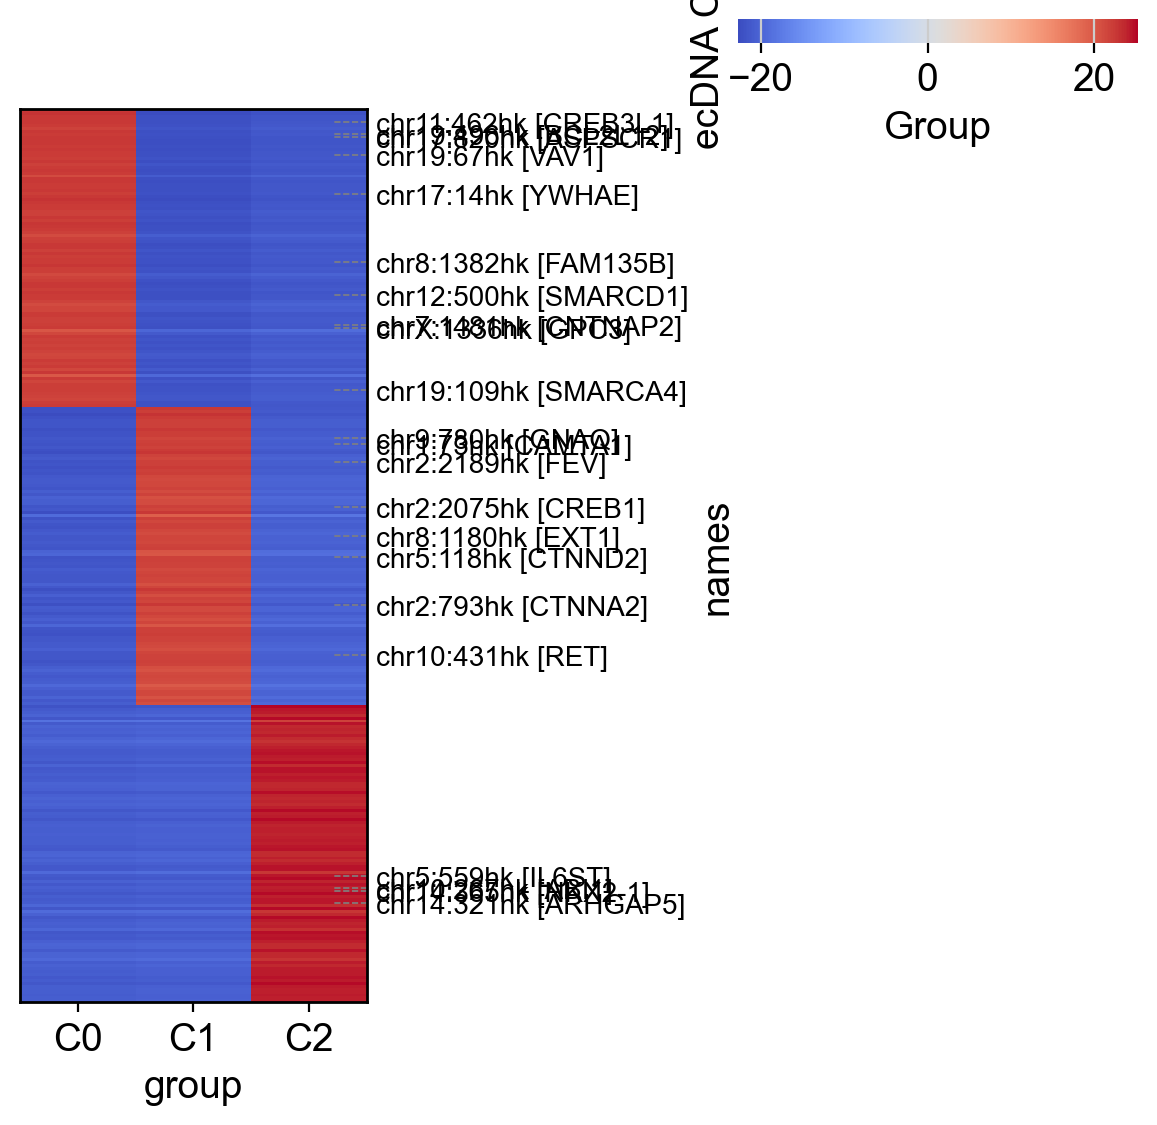

In [219]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: 构建透视表
heatmap_df = new_df.pivot(index="names", columns="group", values="logfoldchanges")

# Step 2: 按 df_ecdna_gene["names"] 顺序重排
ordered_names = df_ecdna_gene["names"]
heatmap_df = heatmap_df.loc[ordered_names]

# Step 3: 构建 yticklabels（只显示 df_filtered 中的）
highlight_names = set(df_filtered["names"])
yticklabels = [
    df_filtered.loc[df_filtered["names"] == name, "names_new2"].values[0]
    if name in highlight_names else ""
    for name in heatmap_df.index
]

# Step 4: 绘图
fig = plt.figure(figsize=(4, 6))
ax = fig.add_subplot(111)
cbar_ax = fig.add_axes([0.95, 0.92, 0.5, 0.02])  # 上方 colorbar

# 绘制热图
sns.heatmap(
    heatmap_df,
    cmap="coolwarm",
    yticklabels=yticklabels,
    xticklabels=True,
    linewidths=0,
    cbar_ax=cbar_ax,
    cbar_kws={"orientation": "horizontal", "label": "logfoldchanges"},
    ax=ax
)

# 设置 Y 轴在右 + 水平显示
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
ax.set_yticklabels(yticklabels, rotation=0, fontsize=10)  # 👈 加了 fontsize 参数
ax.tick_params(axis='y', which='both', length=0)
ax.grid(False)

# 之前的绘图代码保持不变...

# 画“指示线”，从热图右边界往左延伸短横线
n_cols = heatmap_df.shape[1]
line_length = 0.3

for i, label in enumerate(yticklabels):
    if label != "":
        ax.hlines(y=i + 0.5, xmin=n_cols, xmax=n_cols - line_length, colors='gray', linestyles='--', linewidth=0.6)

# ✅ 添加边框
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)

# 设置标签
plt.xlabel("Group")
plt.ylabel("ecDNA CPRs")

# 腾出 colorbar 空间
plt.tight_layout(rect=[0, 0, 1, 0.9])

plt.savefig(f"f06-heatmap_output3.pdf", bbox_inches='tight')
plt.show()